# Train pre-trained ADAGE models on Staph epi data

### Georgia Doing 2022

This notebook walks through traineding pre-trained models on S. epi data
The main objectives are to validate the training workflow using
1. Loss and validation loss curves
2. Node weight distributions
3. Node KEGG and GO enrichments

In [1]:
import run_model_preT
import run_model
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
#from imp import reload
import Adage
from scipy.stats import hypergeom
import csv
from AdageHyperModelv2 import AdageHyperModelv2
import tensorflow as tf
import shap
from keras.models import Model, load_model
import keras_tuner as kt

2025-08-07 12:54:05.336126: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1754585645.357761 1726707 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1754585645.363865 1726707 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1754585645.380336 1726707 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1754585645.380375 1726707 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1754585645.380377 1726707 computation_placer.cc:177] computation placer alr

True


In [8]:
tf.__version__
tf.compat.v1.enable_eager_execution()
print(sys.version)

3.12.10 | packaged by conda-forge | (main, Apr 10 2025, 22:21:13) [GCC 13.3.0]


In [4]:

print("Num CPUs Available: ", len(tf.config.list_physical_devices('CPU')))
print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))
print(tf.test.is_built_with_cuda())

Num CPUs Available:  1
Num GPUs Available:  0
True


In [2]:
seq_temp, seq_temp2 = run_model_preT.run_model('../data_files/se_se16_epi_comp_log_counts_norm_01.csv',
                                               '../data_files/se_se16_epi_comp_log_counts_norm_01.csv',
                                               960, enc_dim = 300, kl1=0, act = 'tanh', tied = True, 
                                               epochs=10, init='glorot_normal', v=0)


tied
made ae


2025-08-07 12:54:18.707981: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


fitted
[array([[-0.01935527,  0.00634419, -0.00275722, ...,  0.00772019,
         0.01588255, -0.01245689],
       [-0.00282179,  0.01014461,  0.02649861, ...,  0.02201499,
         0.04612098, -0.03838101],
       [-0.0340946 ,  0.024438  ,  0.00083741, ..., -0.00902258,
        -0.01209741, -0.04298487],
       ...,
       [ 0.0074987 ,  0.04055587,  0.02858574, ...,  0.0061986 ,
         0.00059036,  0.01661803],
       [-0.04285587,  0.00787957, -0.01494846, ..., -0.03874724,
        -0.0026698 ,  0.05672808],
       [-0.03303931, -0.02762916,  0.02951446, ...,  0.02763976,
         0.01006482, -0.00684578]], dtype=float32), array([ 9.22439620e-04, -1.57923240e-03, -1.90924271e-03, -1.31394283e-03,
       -1.14398205e-03,  5.21558919e-04,  1.19927645e-04, -1.95988989e-03,
        8.69667274e-04,  1.57721719e-04, -2.78993510e-04,  3.72784358e-04,
       -2.69929675e-04,  4.35344729e-04,  5.40203473e-04, -1.60276948e-04,
       -1.89483399e-04, -4.43475321e-04,  1.99189017e-04,  1.41

In [3]:
# for dev purposes, while updating run_model.py need to reload
# for dev purposes, while updating run_model.py need to reload
#reload(run_model_preT)
#reload(run_model)
#reload(Adage)

## Base features (from ADAGE)

For the sake of this efficiency, starting with the following parameters:

* hidden features: 300
* epochs: 500
* curruption: 0.01
* batchs zie: 10
* validatoin split: 0.1
* activation: sigmoid
* objective: binary cross-entropy



In [ ]:
#adage_comp = pandas.read_csv('data_files/ADAGE_compendium.csv')
all_comp = np.loadtxt(open('../data_files/se16_log_counts_norm_01_nonames.csv', "rb"),delimiter=',',skiprows = 1)
gene_num = np.size(all_comp, 0)
samp_num = np.size(all_comp, 1)
print(gene_num, samp_num)
fig = sns.histplot(all_comp.flatten(), bins = 50)

In [ ]:
m = run_model_preT.test_model('../data_files/se_se16_epi_comp_log_counts_norm_01.csv',960)

In [11]:
tune_params0, hist0 = run_model_preT.tune_model('../data_files/sepi_pan_genome_log_counts_norm_01.csv',961)
tune_params1, hist1 = run_model_preT.tune_model('../data_files/saur_pan_genome_log_counts_norm_01.csv',961)
#tune_params1, hist1 = run_model_preT.tune_model('../data_files/saur_pan_genome_log_counts_norm_01.csv',961)
#tune_params2, hist2 = run_model_preT.tune_model('../data_files/se_se16_epi_comp_log_counts_norm_01.csv',962)
#tune_params3, hist3 = run_model_preT.tune_model('../data_files/se_se16_epi_comp_log_counts_norm_01.csv',963)
#tune_params4, hist4 = run_model_preT.tune_model('../data_files/se_se16_epi_comp_log_counts_norm_01.csv',964)

Trial 43 Complete [00h 00m 04s]
val_loss: 0.020003346726298332

Best val_loss So Far: 0.006146781612187624
Total elapsed time: 00h 02m 11s

Search: Running Trial #44

Value             |Best Value So Far |Hyperparameter
70                |100               |units
tanh              |sigmoid           |act1
True              |True              |shuffle
glorot_normal     |glorot_uniform    |init
0.3               |0.2               |kl1
0.5               |0.9               |kl2
0.6               |0.3               |al2
0.051             |0.061             |lr
10                |20                |bs
0                 |0                 |tied
relu              |tanh              |act2
6                 |6                 |tuner/epochs
2                 |2                 |tuner/initial_epoch
3                 |3                 |tuner/bracket
1                 |1                 |tuner/round
0020              |0001              |tuner/trial_id

Epoch 3/6
160/300 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms

IOPub message rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_msg_rate_limit`.

Current values:
ServerApp.iopub_msg_rate_limit=1000.0 (msgs/sec)
ServerApp.rate_limit_window=3.0 (secs)



In [3]:
#print(len(hist.history['loss']))

hist0.results_summary()

#hist1.results_summary()
#hist2.results_summary()
#hist3.results_summary()
#hist4.results_summary()
#model = tuner.hypermodel.build(best_hps[0])
#hist  = tuner.hypermodel.fit(best_hps[0], model) 



NameError: name 'hist0' is not defined

In [7]:
all_comp = np.loadtxt(open('../data_files/se16_log_counts_norm_01_nonames.csv', "rb"),delimiter=',',skiprows = 1)
gene_num = np.size(all_comp, 0)
tunerSE = kt.Hyperband(
    hypermodel=AdageHyperModelv2(input_shape=gene_num),
    #hyperparameters = hp,
    #objective = "val_loss", 
    #max_epochs=50, 
    overwrite=False,  
    directory='/work/gd134/hyperband_search_dir', 
    project_name='sepi_pan_genome_log_counts_norm_01_960')

tunerSA = kt.Hyperband(
    hypermodel=AdageHyperModelv2(input_shape=gene_num),
    #hyperparameters = hp,
    #objective = "val_loss", 
    #max_epochs=50, 
    overwrite=False,  
    directory='/work/gd134/hyperband_search_dir', 
    project_name='saur_pan_genome_log_counts_norm_01_960')

Reloading Tuner from /work/gd134/hyperband_search_dir/sepi_pan_genome_log_counts_norm_01_960/tuner0.json
Reloading Tuner from /work/gd134/hyperband_search_dir/saur_pan_genome_log_counts_norm_01_960/tuner0.json


In [4]:
tunerSA.search_space_summary()

Search space summary
Default search space size: 11
units (Int)
{'default': None, 'conditions': [], 'min_value': 10, 'max_value': 100, 'step': 10, 'sampling': 'linear'}
act1 (Choice)
{'default': 'sigmoid', 'conditions': [], 'values': ['sigmoid', 'tanh', 'relu'], 'ordered': False}
shuffle (Boolean)
{'default': False, 'conditions': []}
init (Choice)
{'default': 'glorot_uniform', 'conditions': [], 'values': ['glorot_uniform', 'glorot_normal'], 'ordered': False}
kl1 (Float)
{'default': 0.0, 'conditions': [], 'min_value': 0.0, 'max_value': 1.0, 'step': 0.1, 'sampling': 'linear'}
kl2 (Float)
{'default': 0.0, 'conditions': [], 'min_value': 0.0, 'max_value': 1.0, 'step': 0.1, 'sampling': 'linear'}
al2 (Float)
{'default': 0.0, 'conditions': [], 'min_value': 0.0, 'max_value': 1.0, 'step': 0.1, 'sampling': 'linear'}
lr (Float)
{'default': 0.001, 'conditions': [], 'min_value': 0.001, 'max_value': 0.1, 'step': 0.01, 'sampling': 'linear'}
bs (Int)
{'default': None, 'conditions': [], 'min_value': 10, 

In [8]:
tunerSA.results_summary()

Results summary
Results in /work/gd134/hyperband_search_dir/saur_pan_genome_log_counts_norm_01_960
Showing 10 best trials
Objective(name="default_objective", direction="min")

Trial 0050 summary
Hyperparameters:
units: 50
act1: relu
shuffle: True
init: glorot_uniform
kl1: 0.9
kl2: 0.0
al2: 0.7000000000000001
lr: 0.061
bs: 10
tied: 0
act2: tanh
tuner/epochs: 50
tuner/initial_epoch: 17
tuner/bracket: 3
tuner/round: 3
tuner/trial_id: 0046
Score: 0.0039314026944339275

Trial 0051 summary
Hyperparameters:
units: 50
act1: relu
shuffle: True
init: glorot_uniform
kl1: 0.4
kl2: 0.2
al2: 0.30000000000000004
lr: 0.051000000000000004
bs: 10
tied: 0
act2: tanh
tuner/epochs: 50
tuner/initial_epoch: 17
tuner/bracket: 3
tuner/round: 3
tuner/trial_id: 0047
Score: 0.003980118781328201

Trial 0072 summary
Hyperparameters:
units: 90
act1: tanh
shuffle: False
init: glorot_normal
kl1: 0.0
kl2: 0.5
al2: 0.7000000000000001
lr: 0.041
bs: 10
tied: 1
act2: tanh
tuner/epochs: 50
tuner/initial_epoch: 17
tuner/brac

In [9]:
for i in tunerSE.get_best_hyperparameters(num_trials=1):
    print(i.values)
for i in tunerSA.get_best_hyperparameters(num_trials=1):
    print(i.values)

{'units': 90, 'act1': 'sigmoid', 'shuffle': False, 'init': 'glorot_normal', 'kl1': 0.7000000000000001, 'kl2': 0.2, 'al2': 0.30000000000000004, 'lr': 0.061, 'bs': 10, 'tied': 0, 'act2': 'tanh', 'tuner/epochs': 50, 'tuner/initial_epoch': 17, 'tuner/bracket': 3, 'tuner/round': 3, 'tuner/trial_id': '0046'}
{'units': 50, 'act1': 'relu', 'shuffle': True, 'init': 'glorot_uniform', 'kl1': 0.9, 'kl2': 0.0, 'al2': 0.7000000000000001, 'lr': 0.061, 'bs': 10, 'tied': 0, 'act2': 'tanh', 'tuner/epochs': 50, 'tuner/initial_epoch': 17, 'tuner/bracket': 3, 'tuner/round': 3, 'tuner/trial_id': '0046'}


In [10]:
for p in range(5):
    print(tunerSE[p].values)

#for p in range(5):
 #   print(tune_params1[p].values)

#for p in range(5):
 #   print(tune_params2[p].values)

#for p in range(5):
  #  print(tune_params3[p].values)

#for p in range(5):
  #  print(tune_params4[p].values)
    

TypeError: 'Hyperband' object is not subscriptable

In [13]:
#print(tune_params[0].values)
#print(tune_params[1].values)
for i in range(10):
   print(tune_params[i].values) 
print(tune_params[89].values)
ahm = AdageHyperModel(gene_num)
model = ahm.build(tune_params[0])
#hist = ahm.fit(tune_params[0],model)
#print(hist)


NameError: name 'tune_params' is not defined

In [10]:
seq_temp, seq_temp2 = run_model_preT.run_model('../data_files/se_se16_epi_comp_log_counts_norm_01.csv',
                                               '../data_files/se_se16_epi_comp_log_counts_norm_01.csv',
                                               960, enc_dim = 300, kl1=0, act = 'tanh', tied = True, epochs=10, init='glorot_normal')
arr_temp, arr_temp2 = run_model_preT.run_model('../data_files/train_set_normalized.csv',
                                               '../data_files/train_set_normalized.csv',
                                               960,enc_dim = 300, kl1=0, act = 'tanh', tied = True, epochs=10, init='glorot_normal')
tf_adage = Adage.Adage(arr_temp.autoencoder, arr_temp.history, arr_temp.compendium)
tf_weights = np.array(pd.read_csv('../outputs/ADAGE_OG_weights.csv', header = None))
tf_cost = pd.read_csv('../outputs/ADAGE_OG_cost_log.csv')
tf_adage.weights = tf_weights
tf_adage.loss = tf_cost['cost']
tf_adage.set_hwg_cutoff(2.5).shape

updated22
Epoch 1/10
22/22 [==============================] - 0s 6ms/step - loss: 0.7036 - val_loss: 0.7007
Epoch 2/10
22/22 [==============================] - 0s 3ms/step - loss: 0.6987 - val_loss: 0.6959
Epoch 3/10
22/22 [==============================] - 0s 3ms/step - loss: 0.6945 - val_loss: 0.6925
Epoch 4/10
22/22 [==============================] - 0s 3ms/step - loss: 0.6916 - val_loss: 0.6903
Epoch 5/10
22/22 [==============================] - 0s 3ms/step - loss: 0.6897 - val_loss: 0.6887
Epoch 6/10
22/22 [==============================] - 0s 4ms/step - loss: 0.6883 - val_loss: 0.6876
Epoch 7/10
22/22 [==============================] - 0s 4ms/step - loss: 0.6871 - val_loss: 0.6866
Epoch 8/10
22/22 [==============================] - 0s 4ms/step - loss: 0.6862 - val_loss: 0.6857
Epoch 9/10
22/22 [==============================] - 0s 4ms/step - loss: 0.6853 - val_loss: 0.6849
Epoch 10/10
22/22 [==============================] - 0s 4ms/step - loss: 0.6844 - val_loss: 0.6840
(2,)
(2,)

Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.


22/22 [==============================] - 0s 5ms/step - loss: 0.6837 - val_loss: 0.6835
Epoch 2/10
22/22 [==============================] - 0s 3ms/step - loss: 0.6830 - val_loss: 0.6827
Epoch 3/10
22/22 [==============================] - 0s 3ms/step - loss: 0.6821 - val_loss: 0.6819
Epoch 4/10
22/22 [==============================] - 0s 3ms/step - loss: 0.6812 - val_loss: 0.6810
Epoch 5/10
22/22 [==============================] - 0s 3ms/step - loss: 0.6803 - val_loss: 0.6802
Epoch 6/10
22/22 [==============================] - 0s 4ms/step - loss: 0.6794 - val_loss: 0.6793
Epoch 7/10
22/22 [==============================] - 0s 3ms/step - loss: 0.6785 - val_loss: 0.6784
Epoch 8/10
22/22 [==============================] - 0s 3ms/step - loss: 0.6775 - val_loss: 0.6776
Epoch 9/10
22/22 [==============================] - 0s 3ms/step - loss: 0.6766 - val_loss: 0.6767
Epoch 10/10
22/22 [==============================] - 0s 4ms/step - loss: 0.6757 - val_loss: 0.6758
Epoch 1/100
22/22 [===========

Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.


(2,)
(2,)
(2,)
Epoch 1/10
 1/86 [..............................] - ETA: 11s - loss: 0.6711

Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.


86/86 [==============================] - 1s 5ms/step - loss: 0.6703 - val_loss: 0.6724
Epoch 2/10
86/86 [==============================] - 0s 5ms/step - loss: 0.6680 - val_loss: 0.6706
Epoch 3/10
86/86 [==============================] - 0s 5ms/step - loss: 0.6658 - val_loss: 0.6688
Epoch 4/10
86/86 [==============================] - 0s 5ms/step - loss: 0.6637 - val_loss: 0.6672
Epoch 5/10
86/86 [==============================] - 0s 4ms/step - loss: 0.6618 - val_loss: 0.6658
Epoch 6/10
86/86 [==============================] - 0s 4ms/step - loss: 0.6601 - val_loss: 0.6646
Epoch 7/10
86/86 [==============================] - 0s 5ms/step - loss: 0.6585 - val_loss: 0.6635
Epoch 8/10
86/86 [==============================] - 0s 4ms/step - loss: 0.6571 - val_loss: 0.6626
Epoch 9/10
86/86 [==============================] - 0s 5ms/step - loss: 0.6559 - val_loss: 0.6618
Epoch 10/10
86/86 [==============================] - 0s 5ms/step - loss: 0.6548 - val_loss: 0.6611
Epoch 1/100
86/86 [===========

(5549, 600)

In [15]:
inits = ['glorot_uniform', 'glorot_normal']
L1_norm = [0]
L2_norm = [0, .4]
act_fun = ['sigmoid','tanh','relu']
tied = [True]

model_dict2 = {
    #"tf_adage": tf_adage
}

model_dict_pre = {
    #"tf_adage": tf_adage
}

model_dict_seq2 = {
    #"tf_adage": tf_adage
}

for seed in range(1):
    for i in inits:
    #print(i)
        for l in L2_norm:
        #print(l)
            for a in act_fun:
            #print(a)
                for t in tied:
                    name = 'ad_' + i + '_' + str(l) + '_' + a + '_tied' + str(t)+ str(seed+571)
                    print(name)
                    mseqpre , mseq = run_model_preT.run_model('../data_files/saur_pan_genome_CROSS_log_counts_norm_01.csv',
                                                              '../data_files/sepi_pan_genome_log_counts_norm_01.csv',
                                                              seed=seed+571,
                                                              enc_dim = 50,
                                                              kl2=l, 
                                                              act = a, 
                                                              tied = t, 
                                                              epochs=10, 
                                                              init=i, 
                                                              lr = 0.05)
                    #marr = run_model.run_model('../data_files/train_set_normalized.csv',seed=seed+560,kl1=l, act = a, tied = t, epochs=300, init=i, lr = 0.1)

                    #model_dict2[name] = marr
                    model_dict_pre[name] = mseqpre
                    model_dict_seq2[name] = mseq

NameError: name 'tf_adage' is not defined

In [31]:
inits = ['glorot_uniform', 'glorot_normal']
L1_norm = [0]
L2_norm = [0, .4]
act_fun = ['sigmoid','tanh','relu']
tied = [True]

model_dictSE = {
    "tf_adage": tf_adage
}

model_dictSA = {
    "tf_adage": tf_adage
}



for seed in range(1):
    for i in inits:
    #print(i)
        for l in L2_norm:
        #print(l)
            for a in act_fun:
            #print(a)
                for t in tied:
                    name = 'ad_' + i + '_' + str(l) + '_' + a + '_tied' + str(t)+ str(seed+571)
                    print(name)
                    mseqSE = run_model.run_model('../data_files/se_se16_epi_comp_log_counts_norm_01.csv',
                                               seed=seed+571,
                                               enc_dim = 50,
                                               kl2=l, 
                                               act = a, 
                                               tied = t,
                                               epochs=10,
                                               init=i,
                                               lr = 0.05)
                    mseqSA = run_model.run_model('../data_files/sa_NCTC3825_filt_norm_log_01.csv',
                                               seed=seed+571,
                                               enc_dim = 50,
                                               kl2=l, 
                                               act = a, 
                                               tied = t,
                                               epochs=10,
                                               init=i,
                                               lr = 0.05)
                    #marr = run_model.run_model('../data_files/train_set_normalized.csv',seed=seed+560,kl1=l, act = a, tied = t, epochs=300, init=i, lr = 0.1)

                    #model_dict2[name] = marr
                    model_dictSE[name] = mseqSE
                    model_dictSA[name] = mseqSA

ad_glorot_uniform_0_sigmoid_tiedTrue571
Epoch 1/10
22/22 [==============================] - 0s 4ms/step - loss: 0.6937 - val_loss: 0.6929
Epoch 2/10
22/22 [==============================] - 0s 2ms/step - loss: 0.6921 - val_loss: 0.6913
Epoch 3/10
22/22 [==============================] - 0s 2ms/step - loss: 0.6906 - val_loss: 0.6901
Epoch 4/10
22/22 [==============================] - 0s 2ms/step - loss: 0.6894 - val_loss: 0.6889
Epoch 5/10
22/22 [==============================] - 0s 2ms/step - loss: 0.6882 - val_loss: 0.6877
Epoch 6/10
22/22 [==============================] - 0s 2ms/step - loss: 0.6869 - val_loss: 0.6864
Epoch 7/10
22/22 [==============================] - 0s 2ms/step - loss: 0.6854 - val_loss: 0.6850
Epoch 8/10
22/22 [==============================] - 0s 3ms/step - loss: 0.6838 - val_loss: 0.6833
Epoch 9/10
22/22 [==============================] - 0s 2ms/step - loss: 0.6820 - val_loss: 0.6816
Epoch 10/10
22/22 [==============================] - 0s 2ms/step - loss: 0.680

In [32]:
inits = ['glorot_uniform', 'glorot_normal']
L1_norm = [0]
L2_norm = [0, .4]
act_fun = ['sigmoid','tanh','relu']
tied = [True]

model_dict_preCTRL = {
    "tf_adage": tf_adage
}

model_dict_seq2CTRL = {
    "tf_adage": tf_adage
}

for seed in range(1):
    for i in inits:
    #print(i)
        for l in L2_norm:
        #print(l)
            for a in act_fun:
            #print(a)
                for t in tied:
                    name = 'ad_' + i + '_' + str(l) + '_' + a + '_tied' + str(t) + str(seed+571)
                    print(name)
                    mseqpre , mseq = run_model_preT.run_model('../data_files/se_se16_epi_comp_log_counts_norm_01.csv',
                                                              '../data_files/se_se16_epi_comp_log_counts_norm_01.csv',
                                                              seed=seed+571,
                                                              enc_dim = 50,
                                                              kl2=l, 
                                                              act = a, 
                                                              tied = t, 
                                                              epochs=10, 
                                                              init=i, 
                                                              lr = 0.05)
                    #marr = run_model.run_model('../data_files/train_set_normalized.csv',seed=seed+560,kl1=l, act = a, tied = t, epochs=300, init=i, lr = 0.1)

                    #model_dict2[name] = marr
                    model_dict_preCTRL[name] = mseqpre
                    model_dict_seq2CTRL[name] = mseq

ad_glorot_uniform_0_sigmoid_tiedTrue571
updated22
Epoch 1/10
22/22 [==============================] - 0s 4ms/step - loss: 0.6938 - val_loss: 0.6930
Epoch 2/10
22/22 [==============================] - 0s 2ms/step - loss: 0.6921 - val_loss: 0.6914
Epoch 3/10
22/22 [==============================] - 0s 2ms/step - loss: 0.6906 - val_loss: 0.6901
Epoch 4/10
22/22 [==============================] - 0s 2ms/step - loss: 0.6893 - val_loss: 0.6889
Epoch 5/10
22/22 [==============================] - 0s 2ms/step - loss: 0.6880 - val_loss: 0.6876
Epoch 6/10
22/22 [==============================] - 0s 2ms/step - loss: 0.6866 - val_loss: 0.6862
Epoch 7/10
22/22 [==============================] - 0s 2ms/step - loss: 0.6851 - val_loss: 0.6847
Epoch 8/10
22/22 [==============================] - 0s 2ms/step - loss: 0.6834 - val_loss: 0.6830
Epoch 9/10
22/22 [==============================] - 0s 2ms/step - loss: 0.6815 - val_loss: 0.6811
Epoch 10/10
22/22 [==============================] - 0s 2ms/step - l

Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.


22/22 [==============================] - 0s 4ms/step - loss: 0.6778 - val_loss: 0.6779
Epoch 2/10
22/22 [==============================] - 0s 2ms/step - loss: 0.6759 - val_loss: 0.6758
Epoch 3/10
22/22 [==============================] - 0s 2ms/step - loss: 0.6737 - val_loss: 0.6738
Epoch 4/10
22/22 [==============================] - 0s 2ms/step - loss: 0.6715 - val_loss: 0.6717
Epoch 5/10
22/22 [==============================] - 0s 2ms/step - loss: 0.6694 - val_loss: 0.6697
Epoch 6/10
22/22 [==============================] - 0s 2ms/step - loss: 0.6673 - val_loss: 0.6678
Epoch 7/10
22/22 [==============================] - 0s 2ms/step - loss: 0.6653 - val_loss: 0.6659
Epoch 8/10
22/22 [==============================] - 0s 2ms/step - loss: 0.6634 - val_loss: 0.6642
Epoch 9/10
22/22 [==============================] - 0s 3ms/step - loss: 0.6616 - val_loss: 0.6626
Epoch 10/10
22/22 [==============================] - 0s 2ms/step - loss: 0.6598 - val_loss: 0.6610
Epoch 1/100
22/22 [===========

Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.


22/22 [==============================] - 0s 4ms/step - loss: 0.6767 - val_loss: 0.6766
Epoch 2/10
22/22 [==============================] - 0s 2ms/step - loss: 0.6745 - val_loss: 0.6743
Epoch 3/10
22/22 [==============================] - 0s 2ms/step - loss: 0.6720 - val_loss: 0.6719
Epoch 4/10
22/22 [==============================] - 0s 2ms/step - loss: 0.6695 - val_loss: 0.6697
Epoch 5/10
22/22 [==============================] - 0s 2ms/step - loss: 0.6672 - val_loss: 0.6676
Epoch 6/10
22/22 [==============================] - 0s 2ms/step - loss: 0.6650 - val_loss: 0.6655
Epoch 7/10
22/22 [==============================] - 0s 2ms/step - loss: 0.6629 - val_loss: 0.6637
Epoch 8/10
22/22 [==============================] - 0s 2ms/step - loss: 0.6609 - val_loss: 0.6619
Epoch 9/10
22/22 [==============================] - 0s 2ms/step - loss: 0.6591 - val_loss: 0.6603
Epoch 10/10
22/22 [==============================] - 0s 2ms/step - loss: 0.6574 - val_loss: 0.6588
Epoch 1/100
22/22 [===========

...

22/22 [==============================] - 0s 4ms/step - loss: 0.6930 - val_loss: 0.6931
Epoch 2/10
22/22 [==============================] - 0s 2ms/step - loss: 0.6930 - val_loss: 0.6931
Epoch 3/10
22/22 [==============================] - 0s 2ms/step - loss: 0.6930 - val_loss: 0.6931
Epoch 4/10
22/22 [==============================] - 0s 2ms/step - loss: 0.6930 - val_loss: 0.6931
Epoch 5/10
22/22 [==============================] - 0s 2ms/step - loss: 0.6930 - val_loss: 0.6931
Epoch 6/10
22/22 [==============================] - 0s 2ms/step - loss: 0.6930 - val_loss: 0.6931
Epoch 7/10
22/22 [==============================] - 0s 3ms/step - loss: 0.6930 - val_loss: 0.6931
Epoch 8/10
22/22 [==============================] - 0s 2ms/step - loss: 0.6930 - val_loss: 0.6931
Epoch 9/10
22/22 [==============================] - 0s 2ms/step - loss: 0.6930 - val_loss: 0.6931
Epoch 10/10
22/22 [==============================] - 0s 2ms/step - loss: 0.6930 - val_loss: 0.6931
Epoch 1/100
22/22 [===========

Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.


22/22 [==============================] - 0s 5ms/step - loss: 0.6931 - val_loss: 0.6931
Epoch 2/10
22/22 [==============================] - 0s 2ms/step - loss: 0.6931 - val_loss: 0.6931
Epoch 3/10
22/22 [==============================] - 0s 2ms/step - loss: 0.6931 - val_loss: 0.6931
Epoch 4/10
22/22 [==============================] - 0s 2ms/step - loss: 0.6931 - val_loss: 0.6931
Epoch 5/10
22/22 [==============================] - 0s 2ms/step - loss: 0.6931 - val_loss: 0.6931
Epoch 6/10
22/22 [==============================] - 0s 2ms/step - loss: 0.6931 - val_loss: 0.6931
Epoch 7/10
22/22 [==============================] - 0s 2ms/step - loss: 0.6931 - val_loss: 0.6931
Epoch 8/10
22/22 [==============================] - 0s 2ms/step - loss: 0.6931 - val_loss: 0.6931
Epoch 9/10
22/22 [==============================] - 0s 2ms/step - loss: 0.6931 - val_loss: 0.6931
Epoch 10/10
22/22 [==============================] - 0s 2ms/step - loss: 0.6931 - val_loss: 0.6931
Epoch 1/100
22/22 [===========

Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.


22/22 [==============================] - 0s 4ms/step - loss: 0.6931 - val_loss: 0.6931
Epoch 2/10
22/22 [==============================] - 0s 2ms/step - loss: 0.6931 - val_loss: 0.6931
Epoch 3/10
22/22 [==============================] - 0s 2ms/step - loss: 0.6931 - val_loss: 0.6931
Epoch 4/10
22/22 [==============================] - 0s 2ms/step - loss: 0.6931 - val_loss: 0.6931
Epoch 5/10
22/22 [==============================] - 0s 2ms/step - loss: 0.6931 - val_loss: 0.6931
Epoch 6/10
22/22 [==============================] - 0s 2ms/step - loss: 0.6931 - val_loss: 0.6931
Epoch 7/10
22/22 [==============================] - 0s 2ms/step - loss: 0.6931 - val_loss: 0.6931
Epoch 8/10
22/22 [==============================] - 0s 2ms/step - loss: 0.6931 - val_loss: 0.6931
Epoch 9/10
22/22 [==============================] - 0s 2ms/step - loss: 0.6931 - val_loss: 0.6931
Epoch 10/10
22/22 [==============================] - 0s 2ms/step - loss: 0.6931 - val_loss: 0.6931
Epoch 1/100
22/22 [===========

[Text(0.5, 1.0, 'tf_adage')]

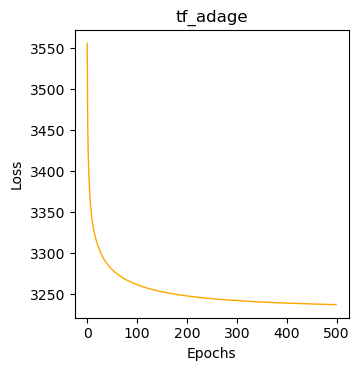

In [33]:
yd = 1 #len(inits) * len(L1_norm)
xd = 1 #len(act_fun) * len(tied)
fig, ax = plt.subplots(xd, yd,figsize=(xd*4 ,yd *4))
fig.tight_layout(pad=3.0)


#name = 'ad_' + i + '_' + str(l) + '_' + a + '_tied' + str(t) + str(460)
                #print(name)
name = 'tf_adage'
model_temp = model_dict_seq2[name]
ax.plot(list(range(0,500)), model_temp.loss, linewidth=1, markersize=2, color = 'orange')
ax.set(title = name, xlabel = 'Epochs', ylabel = 'Loss')
#ax.axvline(x = np.std(model_temp.weights)*2.5)
#ax.axvline(x = np.std(model_temp.weights)*-2.5)
ax.set(title = name)
#ax.set_yscale('log')



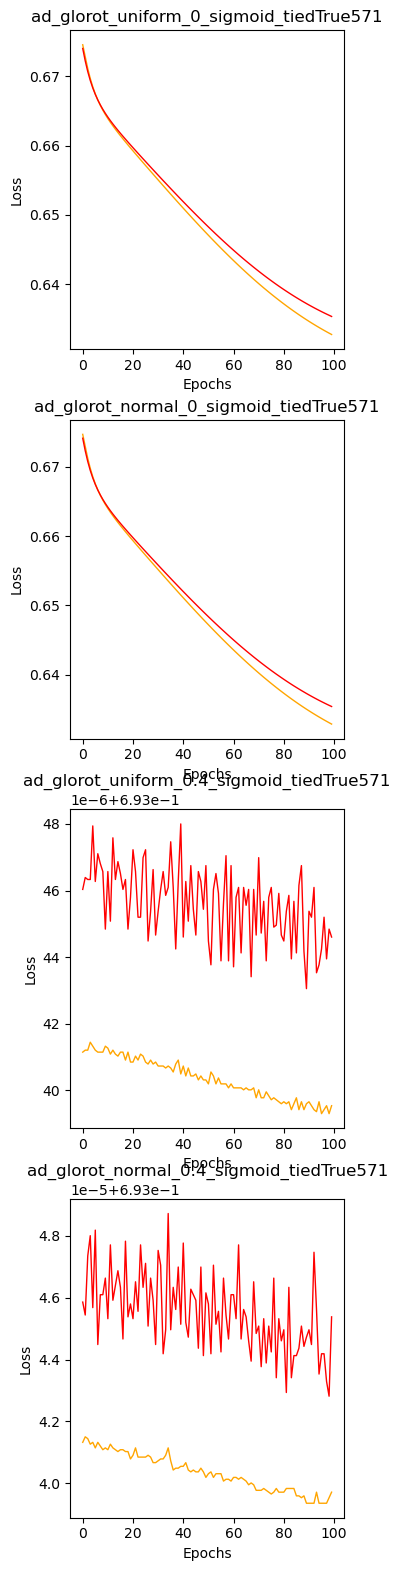

In [26]:
model_dict = model_dict_seq2

yd = len(inits) * len(L2_norm)
xd = len(act_fun) * len(tied)
fig, ax = plt.subplots(xd, yd,figsize=(xd*4 ,yd *4))
fig.tight_layout(pad=3.0)

xi = 0
yi = 0
for l in L2_norm:
    for i in inits:
        xi = 0
        for a in act_fun:
            for t in tied:
                name = 'ad_' + i + '_' + str(l) + '_' + a + '_tied' + str(t) + str(571)
                #print(name)
                model_temp = model_dict[name]
                ax[xi,yi].plot(list(range(0,100)), model_temp.loss, linewidth=1, markersize=2, color = 'orange')
                ax[xi,yi].plot(list(range(0,100)), model_temp.val_loss, linewidth=1, markersize=2, color = 'red')
                ax[xi,yi].set(title = name, xlabel = 'Epochs', ylabel = 'Loss')
                xi = xi+1
        yi=yi+1


    

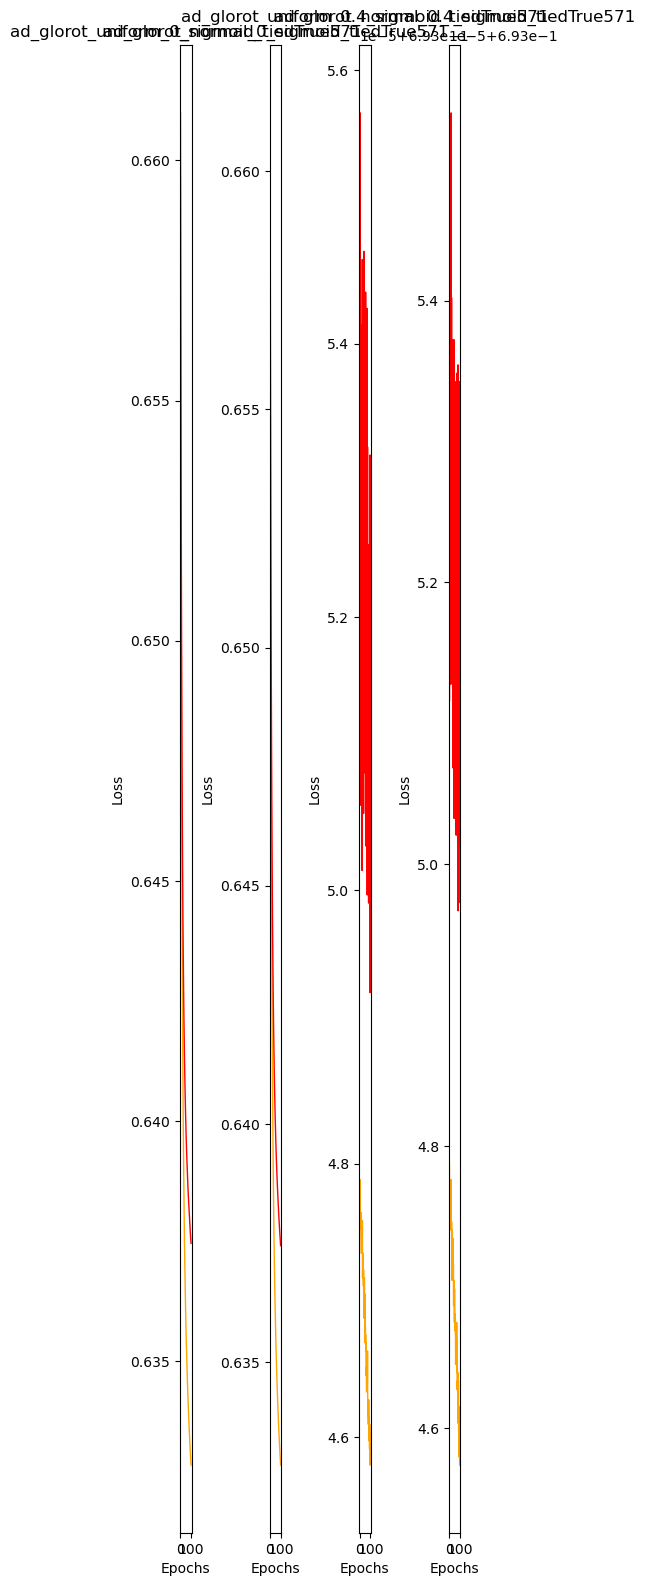

In [29]:
model_dict = model_dict_seq2CTRL

yd = len(inits) * len(L2_norm)
xd = len(act_fun) * len(tied)
fig, ax = plt.subplots(xd, yd,figsize=(xd*4 ,yd *4))
fig.tight_layout(pad=3.0)

xi = 0
yi = 0
for l in L2_norm:
    for i in inits:
        xi = 0
        for a in act_fun:
            for t in tied:
                name = 'ad_' + i + '_' + str(l) + '_' + a + '_tied' + str(t) + str(571)
                #print(name)
                model_temp = model_dict[name]
                ax[yi].plot(list(range(0,100)), model_temp.loss, linewidth=1, markersize=2, color = 'orange')
                ax[yi].plot(list(range(0,100)), model_temp.val_loss, linewidth=1, markersize=2, color = 'red')
                ax[yi].set(title = name, xlabel = 'Epochs', ylabel = 'Loss')
                xi = xi+1
        yi=yi+1

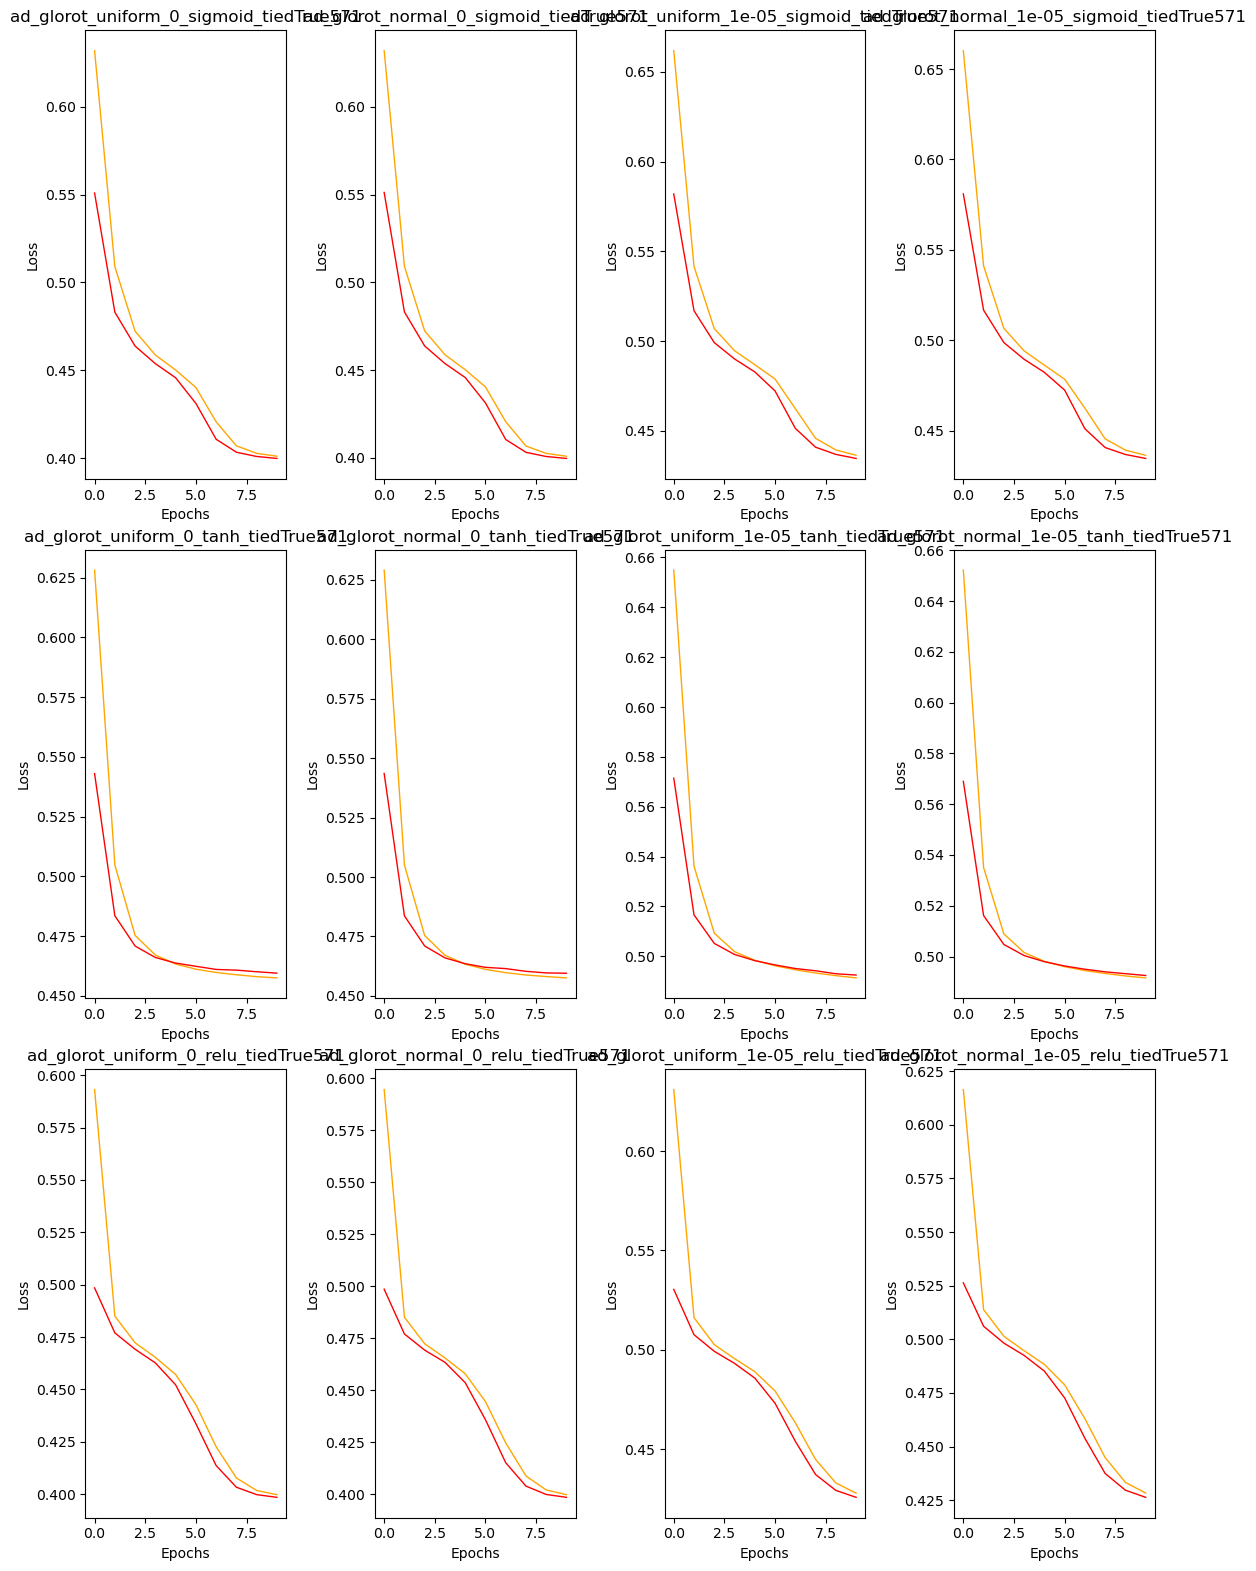

In [15]:
model_dict = model_dict_pre

yd = len(inits) * len(L1_norm)
xd = len(act_fun) * len(tied)
fig, ax = plt.subplots(xd, yd,figsize=(xd*4 ,yd *4))
fig.tight_layout(pad=3.0)

xi = 0
yi = 0
for l in L1_norm:
    for i in inits:
        xi = 0
        for a in act_fun:
            for t in tied:
                name = 'ad_' + i + '_' + str(l) + '_' + a + '_tied' + str(t) + str(571)
                #print(name)
                model_temp = model_dict[name]
                ax[xi,yi].plot(list(range(0,10)), model_temp.loss, linewidth=1, markersize=2, color = 'orange')
                ax[xi,yi].plot(list(range(0,10)), model_temp.val_loss, linewidth=1, markersize=2, color = 'red')
                ax[xi,yi].set(title = name, xlabel = 'Epochs', ylabel = 'Loss')
                xi = xi+1
        yi=yi+1


    

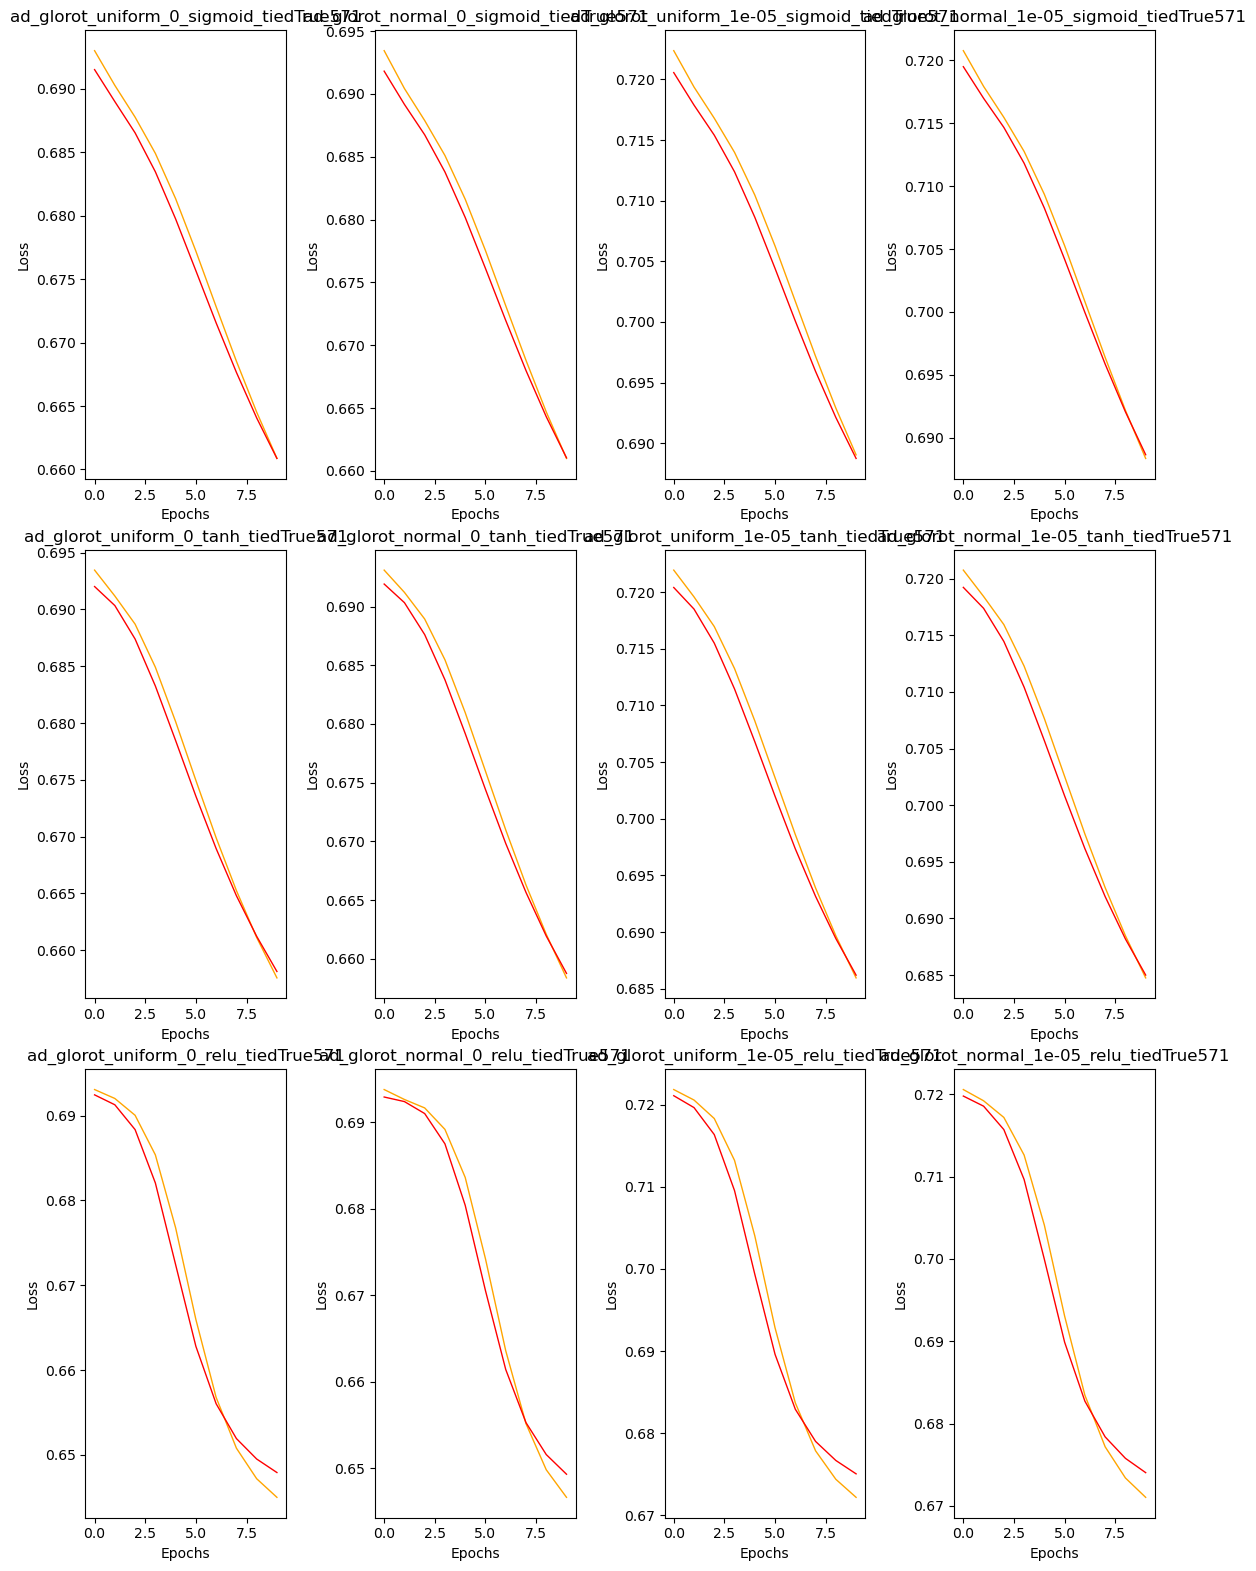

In [16]:
model_dict = model_dict_preCTRL

yd = len(inits) * len(L1_norm)
xd = len(act_fun) * len(tied)
fig, ax = plt.subplots(xd, yd,figsize=(xd*4 ,yd *4))
fig.tight_layout(pad=3.0)

xi = 0
yi = 0
for l in L1_norm:
    for i in inits:
        xi = 0
        for a in act_fun:
            for t in tied:
                name = 'ad_' + i + '_' + str(l) + '_' + a + '_tied' + str(t) + str(571)
                #print(name)
                model_temp = model_dict[name]
                ax[xi,yi].plot(list(range(0,10)), model_temp.loss, linewidth=1, markersize=2, color = 'orange')
                ax[xi,yi].plot(list(range(0,10)), model_temp.val_loss, linewidth=1, markersize=2, color = 'red')
                ax[xi,yi].set(title = name, xlabel = 'Epochs', ylabel = 'Loss')
                xi = xi+1
        yi=yi+1

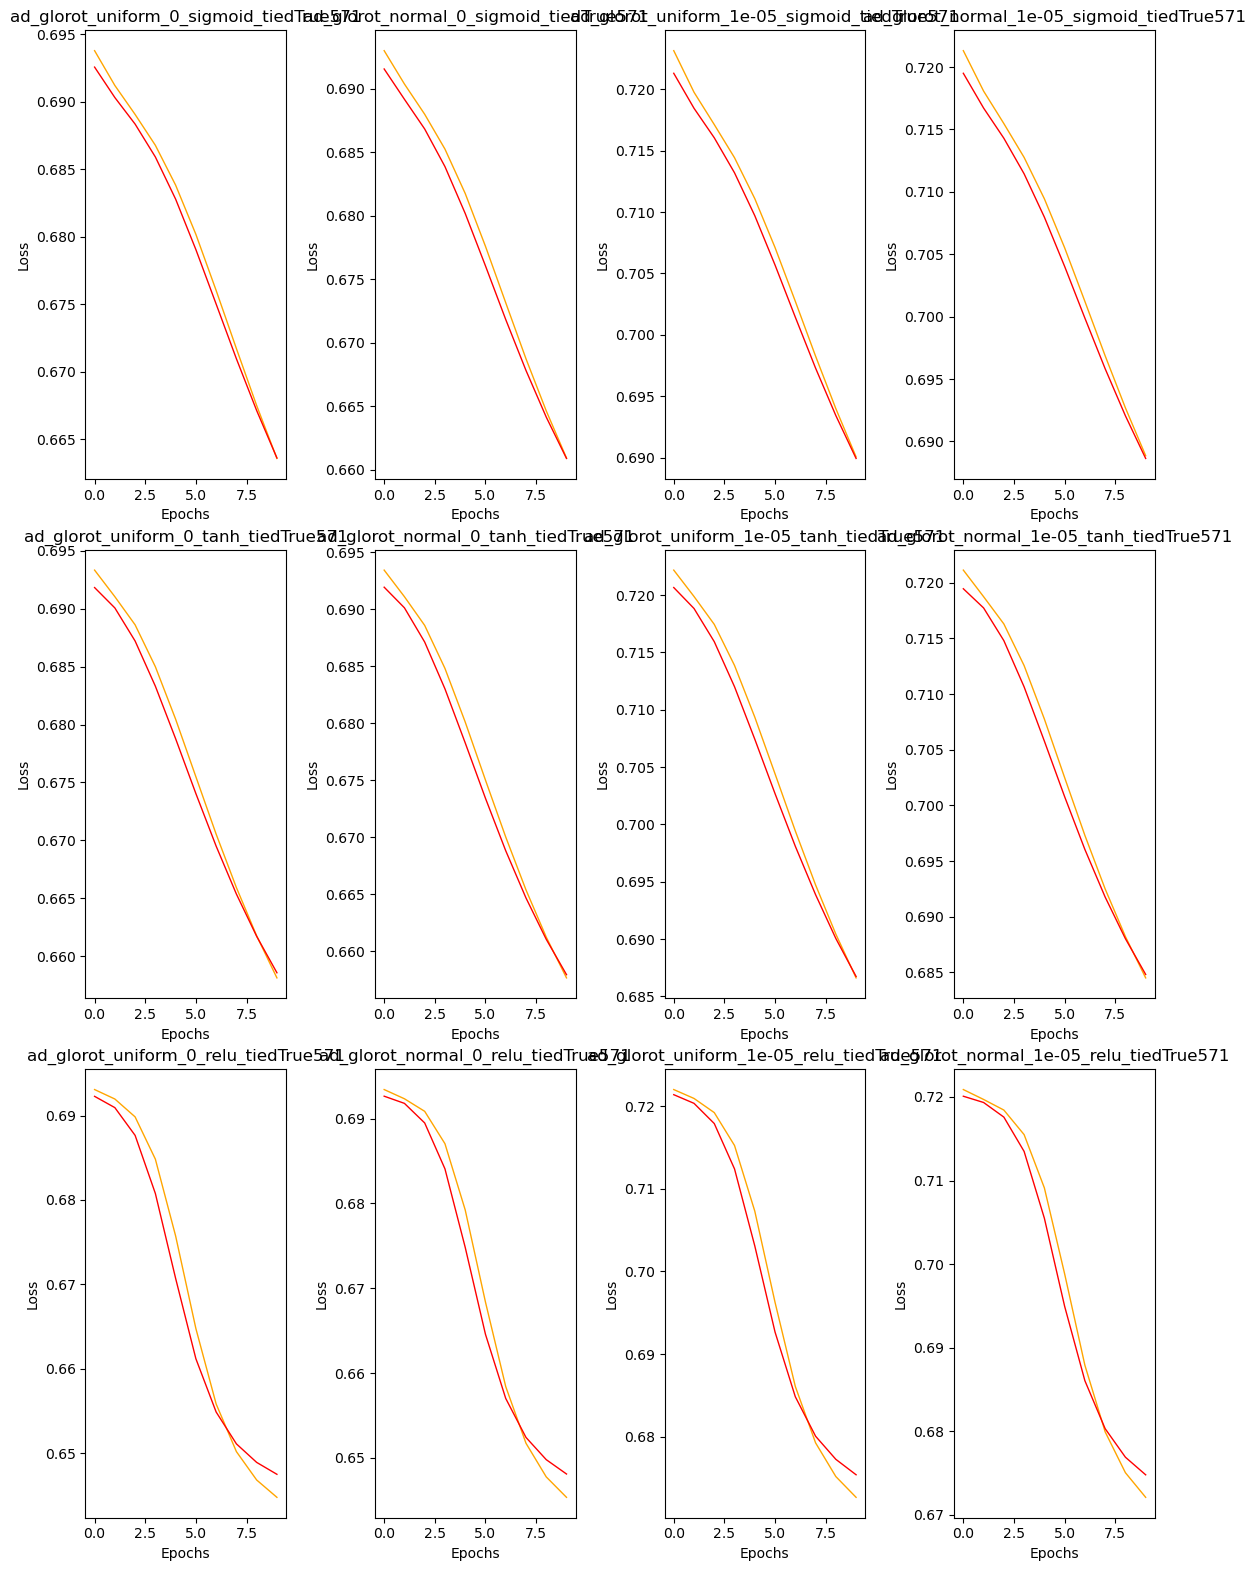

In [17]:
model_dict = model_dictSE

yd = len(inits) * len(L1_norm)
xd = len(act_fun) * len(tied)
fig, ax = plt.subplots(xd, yd,figsize=(xd*4 ,yd *4))
fig.tight_layout(pad=3.0)

xi = 0
yi = 0
for l in L1_norm:
    for i in inits:
        xi = 0
        for a in act_fun:
            for t in tied:
                name = 'ad_' + i + '_' + str(l) + '_' + a + '_tied' + str(t) + str(571)
                #print(name)
                model_temp = model_dict[name]
                ax[xi,yi].plot(list(range(0,10)), model_temp.loss, linewidth=1, markersize=2, color = 'orange')
                ax[xi,yi].plot(list(range(0,10)), model_temp.val_loss, linewidth=1, markersize=2, color = 'red')
                ax[xi,yi].set(title = name, xlabel = 'Epochs', ylabel = 'Loss')
                xi = xi+1
        yi=yi+1

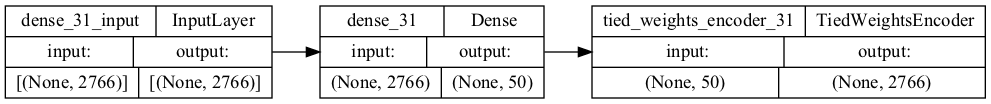

In [53]:
model_dict = model_dictSA
model_temp = model_dict['ad_glorot_uniform_0_sigmoid_tiedTrue571']

tf.keras.utils.plot_model(model_temp.autoencoder, show_shapes=True, rankdir="LR")

In [65]:
comp = model_temp.compendium
print(np.transpose(comp).shape)
x_train2, x_train2_noisy = run_model_preT.prep_data(comp, 571)
print(x_train2.shape, x_train2_noisy.shape)
ae = model_temp.autoencoder 
print(ae)
results = ae.evaluate(x_train2_noisy, x_train2)
print(results)
x_t_both = np.concatenate((x_train2_noisy, x_train2))
print(x_t_both.shape)
predictions = ae.predict(x_t_both)
print(predictions.shape)
print(x_train2[0,0])
print(predictions[0,0])
#print("Accuracy", results[1])

(2153, 2766)
(2153, 2766) (2153, 2766)
68/68 [==============================] - 0s 1ms/step - loss: 0.5933
0.593313455581665
(4306, 2766)
135/135 [==============================] - 0s 767us/step
(4306, 2766)
0.0
0.2139921


In [68]:
#explainer = shap.KernelExplainer(ae, x_t_both[:5,:])
#shap_values = explainer.shap_values(x_t_both[0,:], nsamples = 2767)
#shap.force_plot(explainer.expected_value, shap_values[0], x_train2[20,:])

KeyboardInterrupt: 

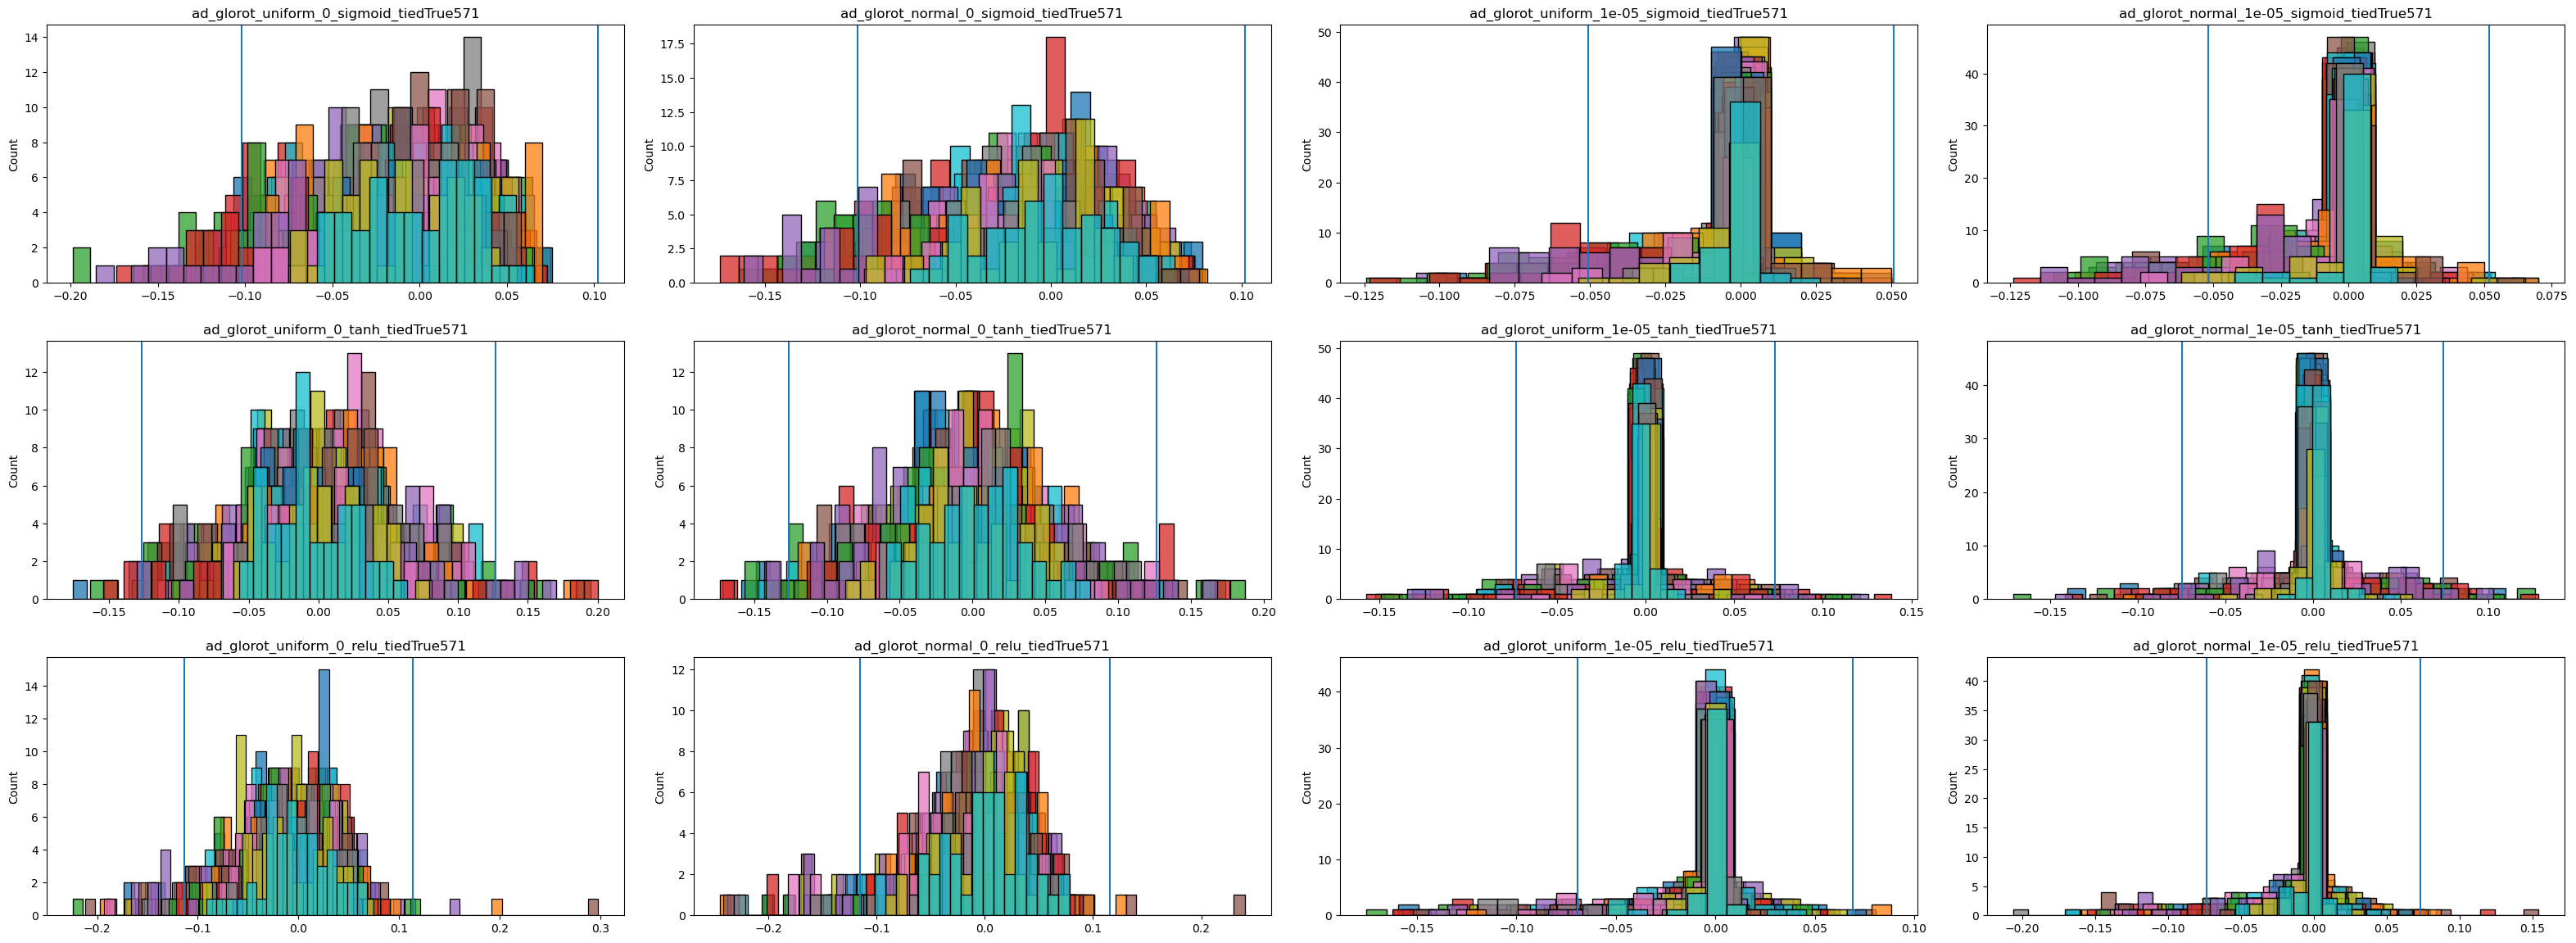

In [34]:
yd = len(inits) * len(L1_norm)
xd = len(act_fun) * len(tied)
fig, ax = plt.subplots(xd, yd,figsize=(yd*8 ,xd *4))
fig.tight_layout(pad=3.0)

xi = 0
yi = 0
for l in L1_norm:
    for i in inits:
        xi = 0
        for a in act_fun:
            for t in tied:
                name = 'ad_' + i + '_' + str(l) + '_' + a + '_tied' + str(t) + str(571)
                #print(name)
                model_temp = model_dict_seq2[name]
                for node in range(0,100):
                    sns.histplot(model_temp.weights[node], #[model_temp.weights[node] > 0],
                        ax=ax[xi,yi],
                        #hist=True,
                        binwidth = 0.01, 
                        #stat="density",
                        kde=False
                        #rug=False
                                )
                ax[xi,yi].axvline(x = np.std(model_temp.weights)*2.5)
                ax[xi,yi].axvline(x = np.std(model_temp.weights)*-2.5)
                ax[xi,yi].set(title = name)
                xi = xi+1
        yi=yi+1


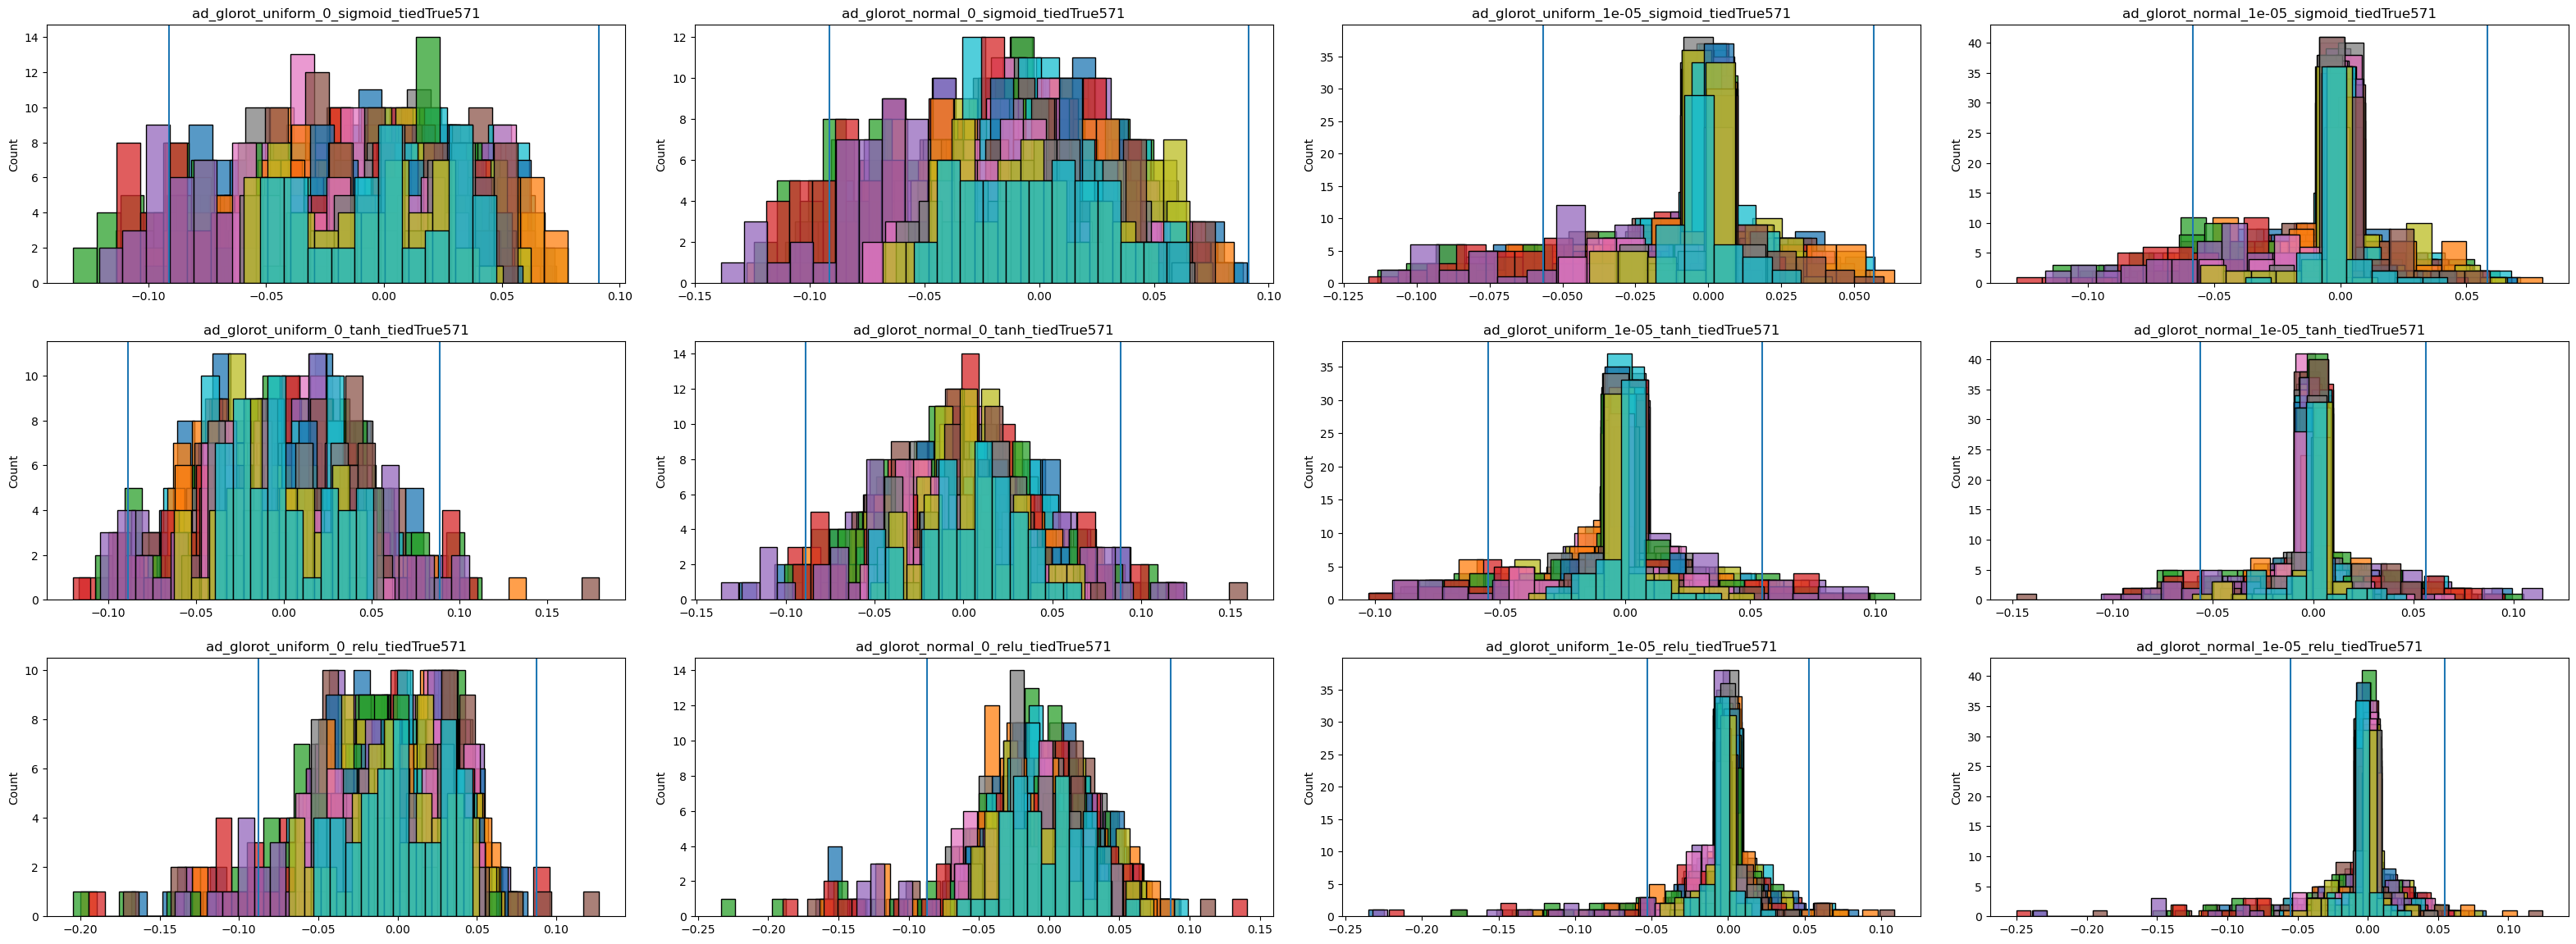

In [35]:
yd = len(inits) * len(L1_norm)
xd = len(act_fun) * len(tied)
fig, ax = plt.subplots(xd, yd,figsize=(yd*8 ,xd *4))
fig.tight_layout(pad=3.0)

xi = 0
yi = 0
for l in L1_norm:
    for i in inits:
        xi = 0
        for a in act_fun:
            for t in tied:
                name = 'ad_' + i + '_' + str(l) + '_' + a + '_tied' + str(t) + str(571)
                #print(name)
                model_temp = model_dict_seq2CTRL[name]
                for node in range(0,100):
                    sns.histplot(model_temp.weights[node], #[model_temp.weights[node] > 0],
                        ax=ax[xi,yi],
                        #hist=True,
                        binwidth = 0.01, 
                        #stat="density",
                        kde=False
                        #rug=False
                                )
                ax[xi,yi].axvline(x = np.std(model_temp.weights)*2.5)
                ax[xi,yi].axvline(x = np.std(model_temp.weights)*-2.5)
                ax[xi,yi].set(title = name)
                xi = xi+1
        yi=yi+1

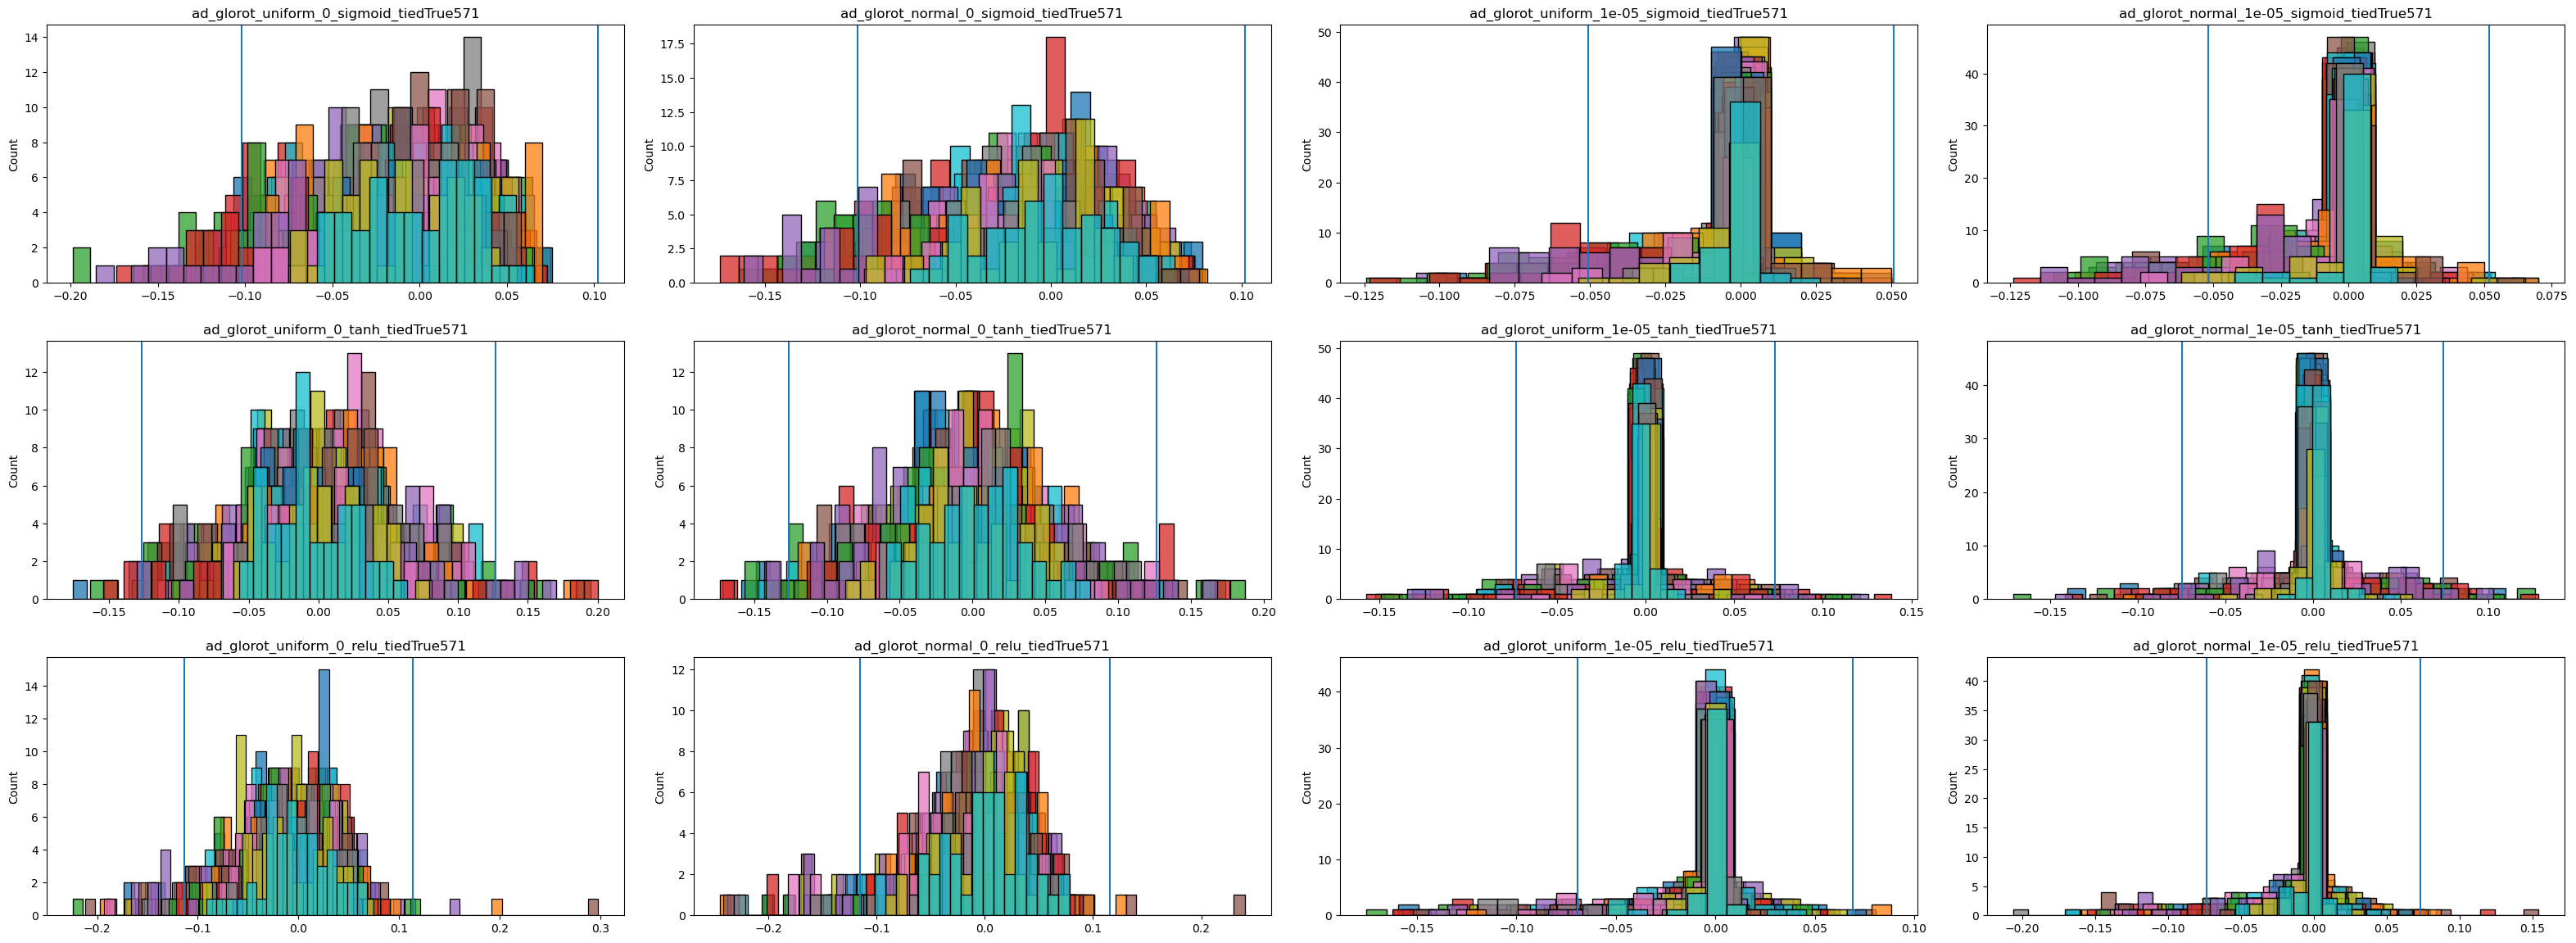

In [37]:
yd = len(inits) * len(L1_norm)
xd = len(act_fun) * len(tied)
fig, ax = plt.subplots(xd, yd,figsize=(yd*8 ,xd *4))
fig.tight_layout(pad=3.0)

xi = 0
yi = 0
for l in L1_norm:
    for i in inits:
        xi = 0
        for a in act_fun:
            for t in tied:
                name = 'ad_' + i + '_' + str(l) + '_' + a + '_tied' + str(t) + str(571)
                #print(name)
                model_temp = model_dict_seq2[name]
                for node in range(0,100):
                    sns.histplot(model_temp.weights[node], #[model_temp.weights[node] > 0],
                        ax=ax[xi,yi],
                        #hist=True,
                        binwidth = 0.01, 
                        #stat="density",
                        kde=False
                        #rug=False
                                )
                ax[xi,yi].axvline(x = np.std(model_temp.weights)*2.5)
                ax[xi,yi].axvline(x = np.std(model_temp.weights)*-2.5)
                ax[xi,yi].set(title = name)
                xi = xi+1
        yi=yi+1


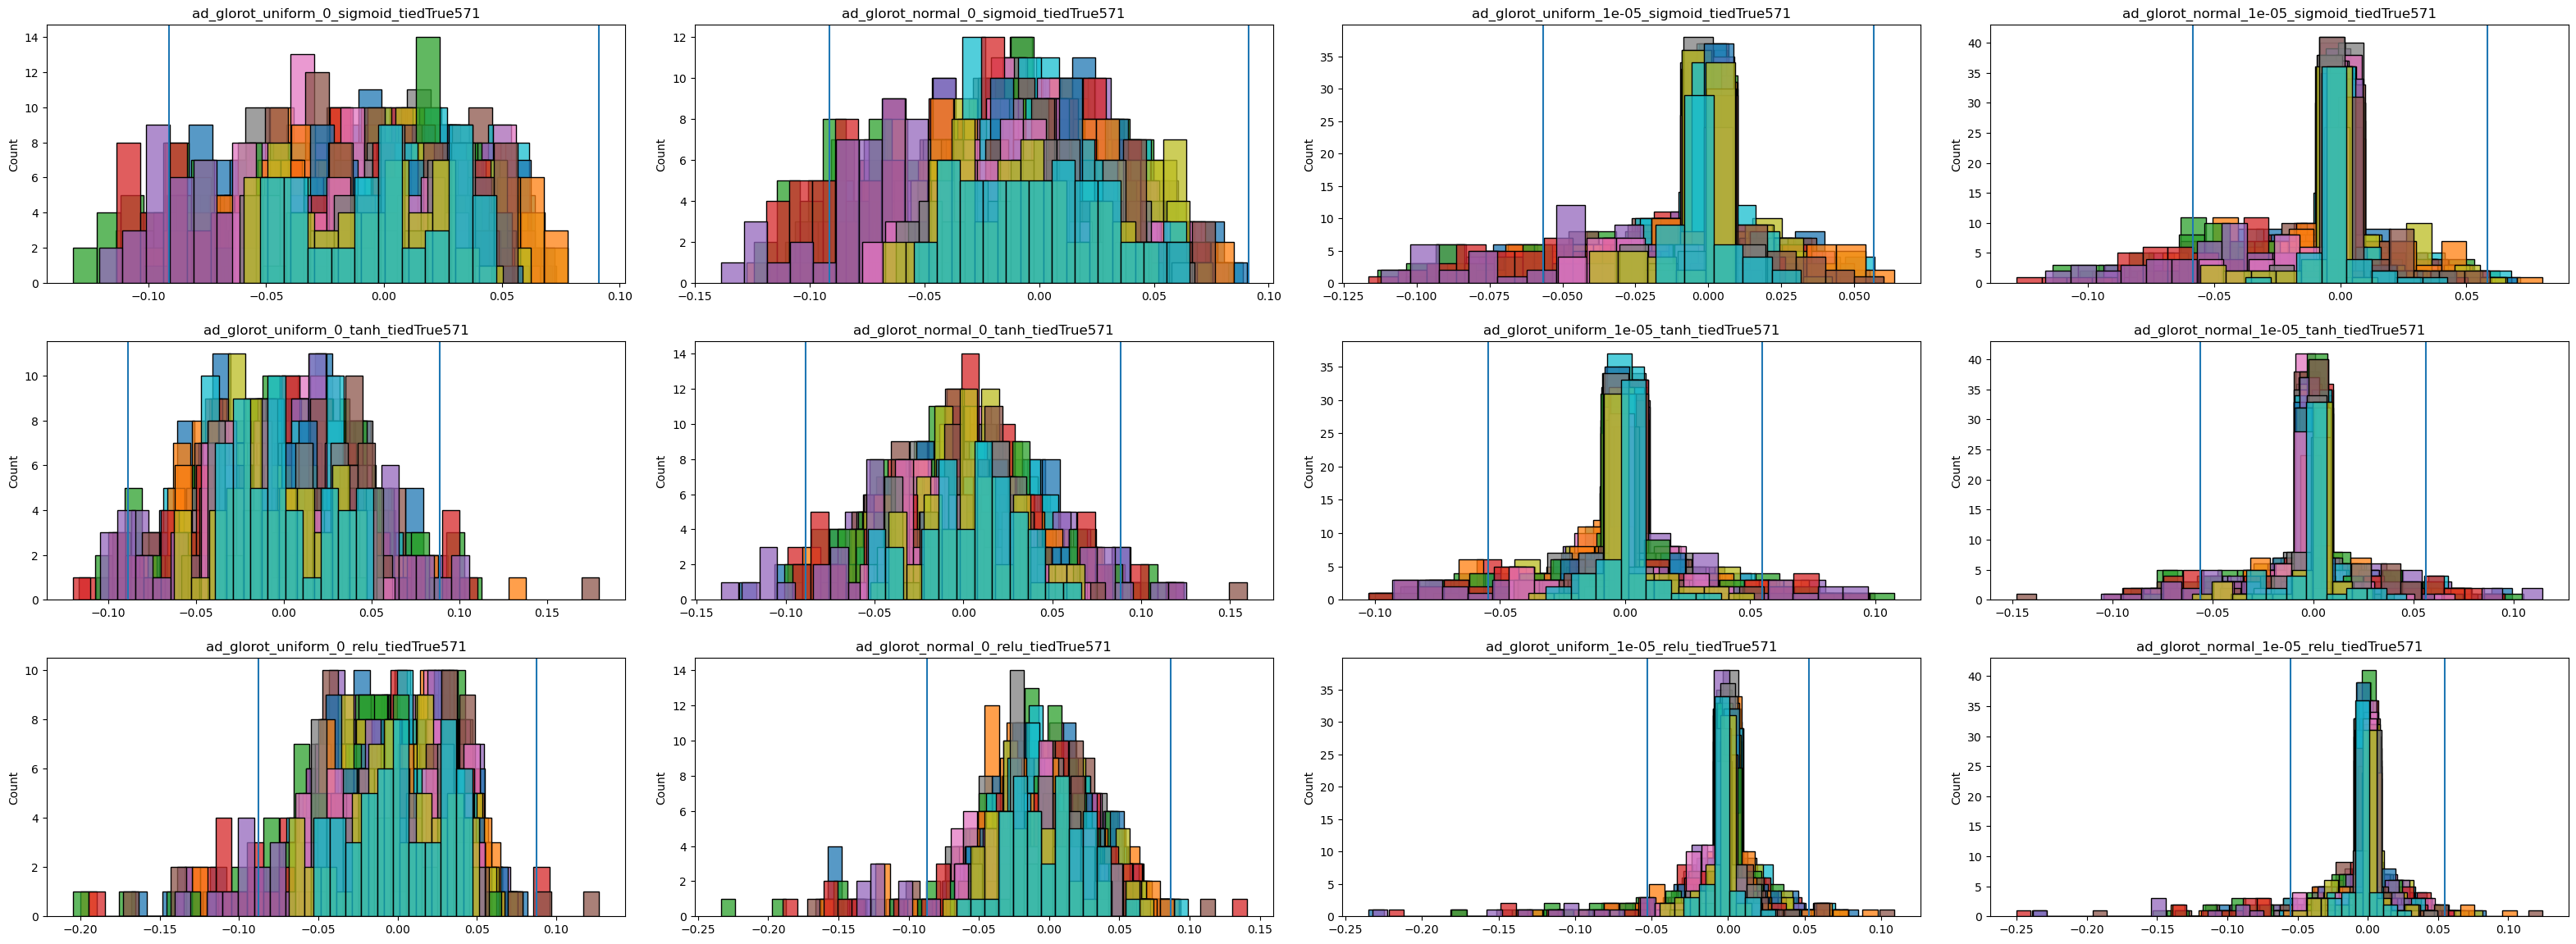

In [38]:
yd = len(inits) * len(L1_norm)
xd = len(act_fun) * len(tied)
fig, ax = plt.subplots(xd, yd,figsize=(yd*8 ,xd *4))
fig.tight_layout(pad=3.0)

xi = 0
yi = 0
for l in L1_norm:
    for i in inits:
        xi = 0
        for a in act_fun:
            for t in tied:
                name = 'ad_' + i + '_' + str(l) + '_' + a + '_tied' + str(t) + str(571)
                #print(name)
                model_temp = model_dict_seq2CTRL[name]
                for node in range(0,100):
                    sns.histplot(model_temp.weights[node], #[model_temp.weights[node] > 0],
                        ax=ax[xi,yi],
                        #hist=True,
                        binwidth = 0.01, 
                        #stat="density",
                        kde=False
                        #rug=False
                                )
                ax[xi,yi].axvline(x = np.std(model_temp.weights)*2.5)
                ax[xi,yi].axvline(x = np.std(model_temp.weights)*-2.5)
                ax[xi,yi].set(title = name)
                xi = xi+1
        yi=yi+1


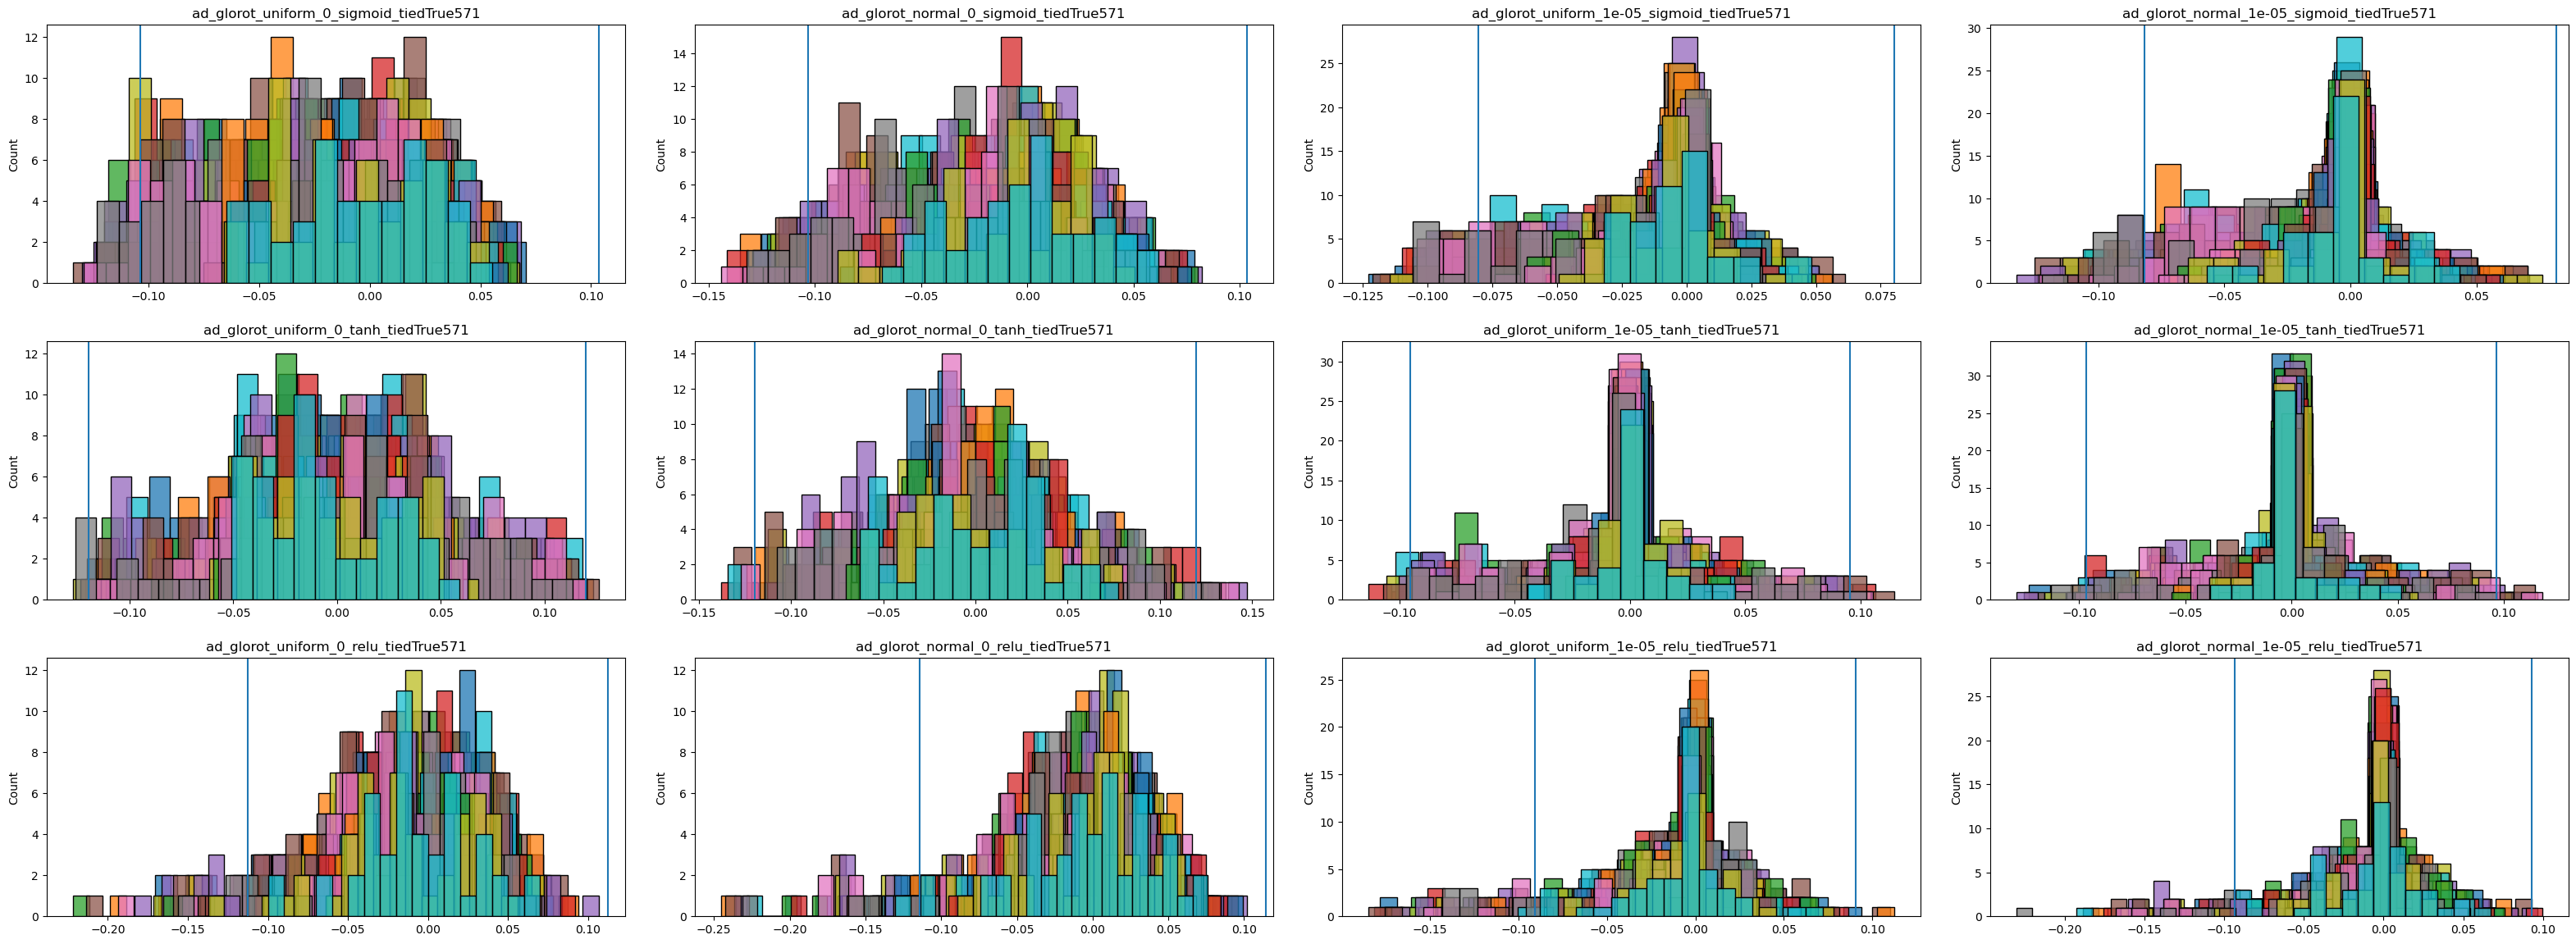

In [39]:
yd = len(inits) * len(L1_norm)
xd = len(act_fun) * len(tied)
fig, ax = plt.subplots(xd, yd,figsize=(yd*8 ,xd *4))
fig.tight_layout(pad=3.0)

xi = 0
yi = 0
for l in L1_norm:
    for i in inits:
        xi = 0
        for a in act_fun:
            for t in tied:
                name = 'ad_' + i + '_' + str(l) + '_' + a + '_tied' + str(t) + str(571)
                #print(name)
                model_temp = model_dict_pre[name]
                for node in range(0,100):
                    sns.histplot(model_temp.weights[node], #[model_temp.weights[node] > 0],
                        ax=ax[xi,yi],
                        #hist=True,
                        binwidth = 0.01, 
                        #stat="density",
                        kde=False
                        #rug=False
                                )
                ax[xi,yi].axvline(x = np.std(model_temp.weights)*2.5)
                ax[xi,yi].axvline(x = np.std(model_temp.weights)*-2.5)
                ax[xi,yi].set(title = name)
                xi = xi+1
        yi=yi+1

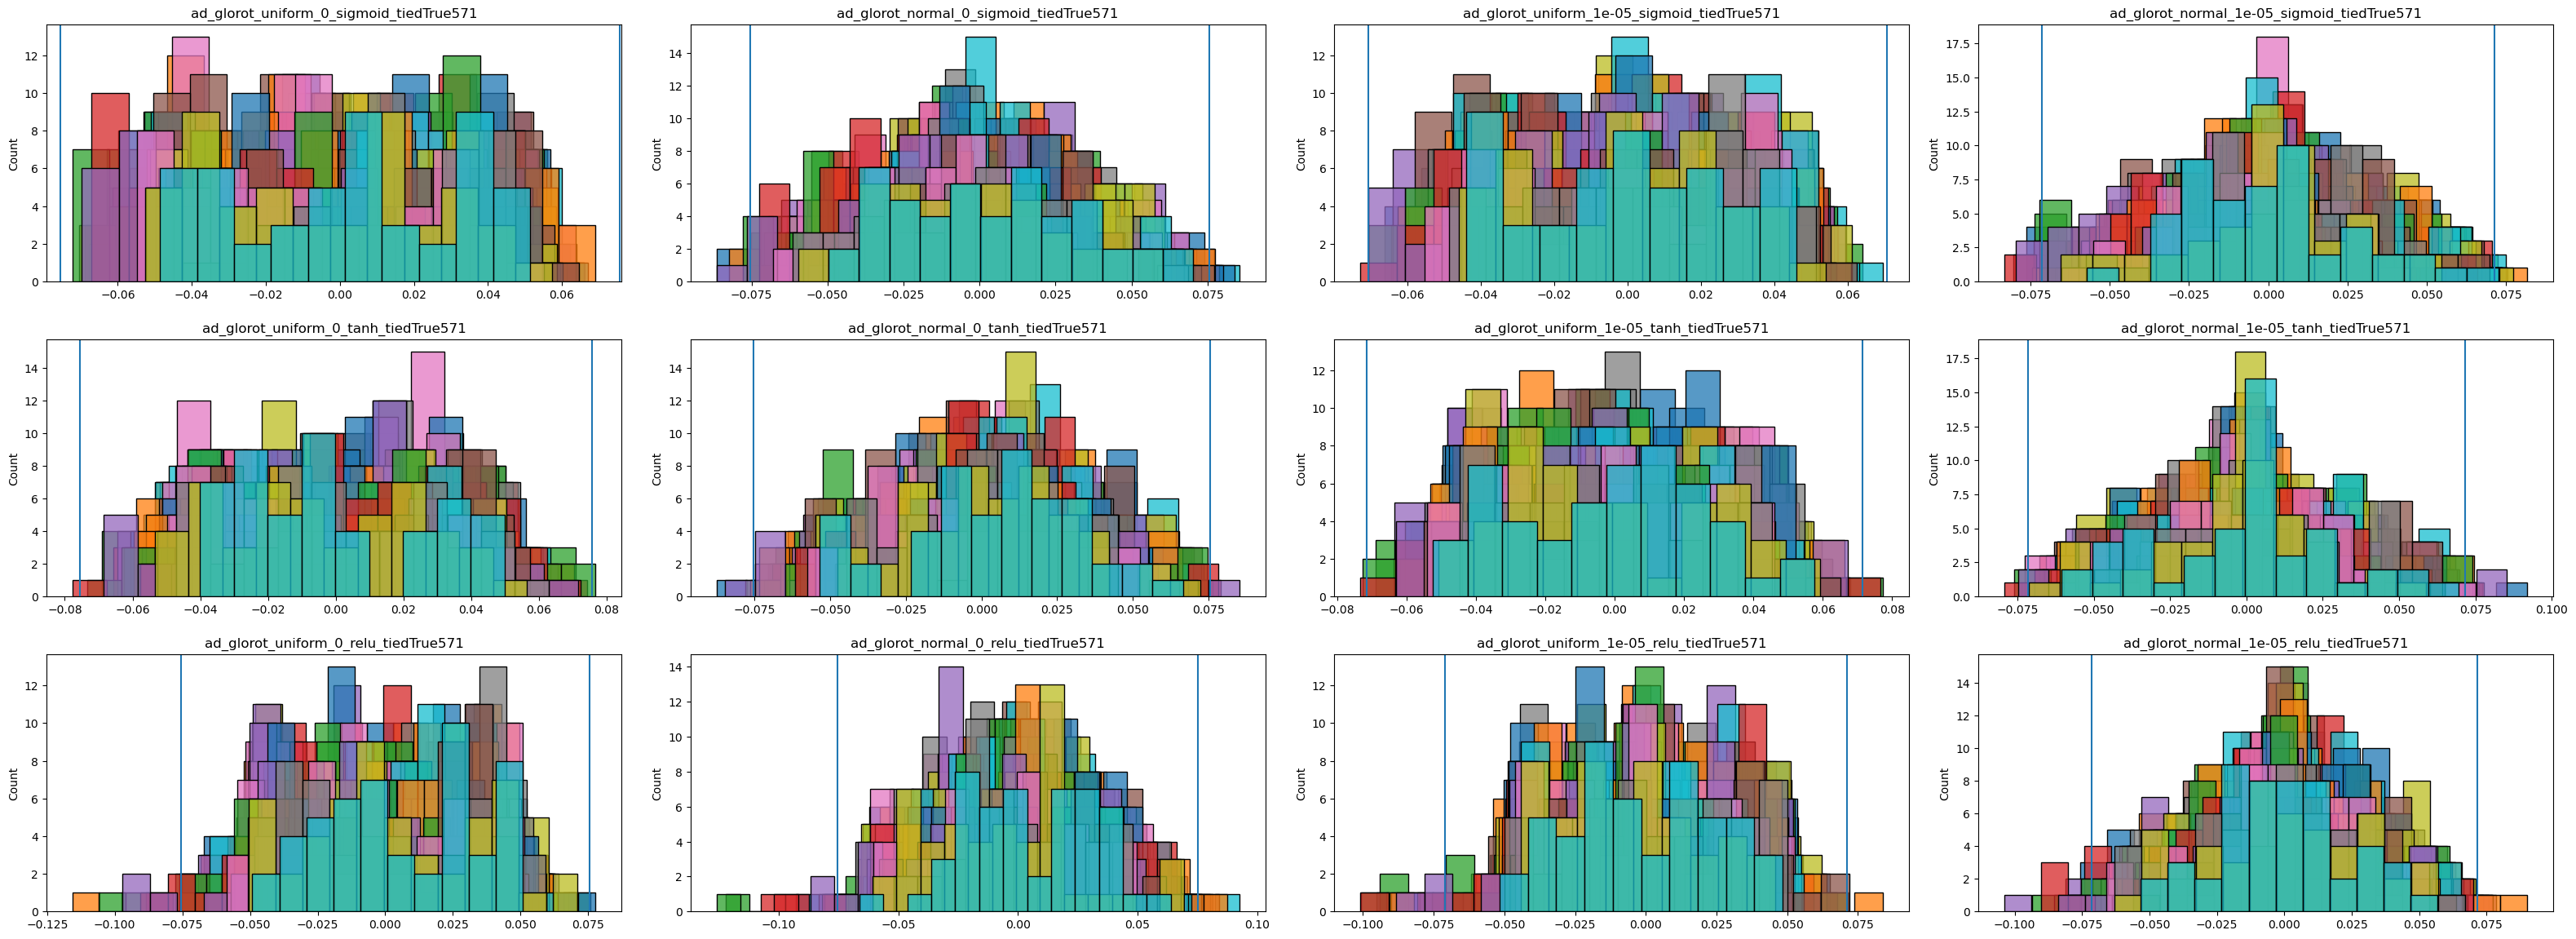

In [40]:
yd = len(inits) * len(L1_norm)
xd = len(act_fun) * len(tied)
fig, ax = plt.subplots(xd, yd,figsize=(yd*8 ,xd *4))
fig.tight_layout(pad=3.0)

xi = 0
yi = 0
for l in L1_norm:
    for i in inits:
        xi = 0
        for a in act_fun:
            for t in tied:
                name = 'ad_' + i + '_' + str(l) + '_' + a + '_tied' + str(t) + str(571)
                #print(name)
                model_temp = model_dict_preCTRL[name]
                for node in range(0,100):
                    sns.histplot(model_temp.weights[node], #[model_temp.weights[node] > 0],
                        ax=ax[xi,yi],
                        #hist=True,
                        binwidth = 0.01, 
                        #stat="density",
                        kde=False
                        #rug=False
                                )
                ax[xi,yi].axvline(x = np.std(model_temp.weights)*2.5)
                ax[xi,yi].axvline(x = np.std(model_temp.weights)*-2.5)
                ax[xi,yi].set(title = name)
                xi = xi+1
        yi=yi+1

In [41]:
model_temp = model_dict_seq2
#del model_temp['tf_adage']
for m in model_temp:
    print(m)
    model_dict_seq2[m].set_hwg_cutoff(2.5)
    #model_dict_seq2[m].set_op('../node_interpretation/operons_format.txt')
    #print('op done')
    model_dict_seq2[m].set_kegg('../node_interpretation/se16_KEGG_format.txt') 
    #print('kegg done')
    #model_dict_seq2[m].set_go('../node_interpretation/manual_GO_BP_terms.txt') 
    #print('go done')
    #model_dict_seq2[m].set_reg('../node_interpretation/regulons_format.txt')
    #print('reg done')
print('dict done') 

model_temp = model_dict_seq2CTRL
#del model_temp['tf_adage']
for m in model_temp:
    print(m)
    model_dict_seq2CTRL[m].set_hwg_cutoff(2.5)
    #model_dict_seq2[m].set_op('../node_interpretation/operons_format.txt')
    #print('op done')
    model_dict_seq2CTRL[m].set_kegg('../node_interpretation/se16_KEGG_format.txt') 
    #print('kegg done')
    #model_dict_seq2[m].set_go('../node_interpretation/manual_GO_BP_terms.txt') 
    #print('go done')
    #model_dict_seq2[m].set_reg('../node_interpretation/regulons_format.txt')
    #print('reg done')
print('dict done') 


model_temp = model_dict_pre
#del model_temp['tf_adage']
for m in model_temp:
    print(m)
    model_dict_pre[m].set_hwg_cutoff(2.5)
    #model_dict_seq2[m].set_op('../node_interpretation/operons_format.txt')
    #print('op done')
    model_dict_pre[m].set_kegg('../node_interpretation/se16_KEGG_format.txt') 
    #print('kegg done')
    #model_dict_seq2[m].set_go('../node_interpretation/manual_GO_BP_terms.txt') 
    #print('go done')
    #model_dict_seq2[m].set_reg('../node_interpretation/regulons_format.txt')
    #print('reg done')
print('dict done')


model_temp = model_dict_preCTRL
#del model_temp['tf_adage']
for m in model_temp:
    print(m)
    model_dict_preCTRL[m].set_hwg_cutoff(2.5)
    #model_dict_seq2[m].set_op('../node_interpretation/operons_format.txt')
    #print('op done')
    model_dict_preCTRL[m].set_kegg('../node_interpretation/se16_KEGG_format.txt') 
    #print('kegg done')
    #model_dict_seq2[m].set_go('../node_interpretation/manual_GO_BP_terms.txt') 
    #print('go done')
    #model_dict_seq2[m].set_reg('../node_interpretation/regulons_format.txt')
    #print('reg done')
print('dict done')

tf_adage
ad_glorot_uniform_0_sigmoid_tiedTrue571
ad_glorot_uniform_0_tanh_tiedTrue571
ad_glorot_uniform_0_relu_tiedTrue571
ad_glorot_uniform_1e-05_sigmoid_tiedTrue571
ad_glorot_uniform_1e-05_tanh_tiedTrue571
ad_glorot_uniform_1e-05_relu_tiedTrue571
ad_glorot_normal_0_sigmoid_tiedTrue571
ad_glorot_normal_0_tanh_tiedTrue571
ad_glorot_normal_0_relu_tiedTrue571
ad_glorot_normal_1e-05_sigmoid_tiedTrue571
ad_glorot_normal_1e-05_tanh_tiedTrue571
ad_glorot_normal_1e-05_relu_tiedTrue571
dict done
tf_adage
ad_glorot_uniform_0_sigmoid_tiedTrue571
ad_glorot_uniform_0_tanh_tiedTrue571
ad_glorot_uniform_0_relu_tiedTrue571
ad_glorot_uniform_1e-05_sigmoid_tiedTrue571
ad_glorot_uniform_1e-05_tanh_tiedTrue571
ad_glorot_uniform_1e-05_relu_tiedTrue571
ad_glorot_normal_0_sigmoid_tiedTrue571
ad_glorot_normal_0_tanh_tiedTrue571
ad_glorot_normal_0_relu_tiedTrue571
ad_glorot_normal_1e-05_sigmoid_tiedTrue571
ad_glorot_normal_1e-05_tanh_tiedTrue571
ad_glorot_normal_1e-05_relu_tiedTrue571
dict done
tf_adage
ad_gl

ad_glorot_uniform_0_sigmoid_tiedTrue571
ad_glorot_uniform_0_tanh_tiedTrue571
ad_glorot_uniform_0_relu_tiedTrue571
ad_glorot_uniform_1e-05_sigmoid_tiedTrue571
ad_glorot_uniform_1e-05_tanh_tiedTrue571
ad_glorot_uniform_1e-05_relu_tiedTrue571
ad_glorot_normal_0_sigmoid_tiedTrue571
ad_glorot_normal_0_tanh_tiedTrue571
ad_glorot_normal_0_relu_tiedTrue571
ad_glorot_normal_1e-05_sigmoid_tiedTrue571
ad_glorot_normal_1e-05_tanh_tiedTrue571
ad_glorot_normal_1e-05_relu_tiedTrue571


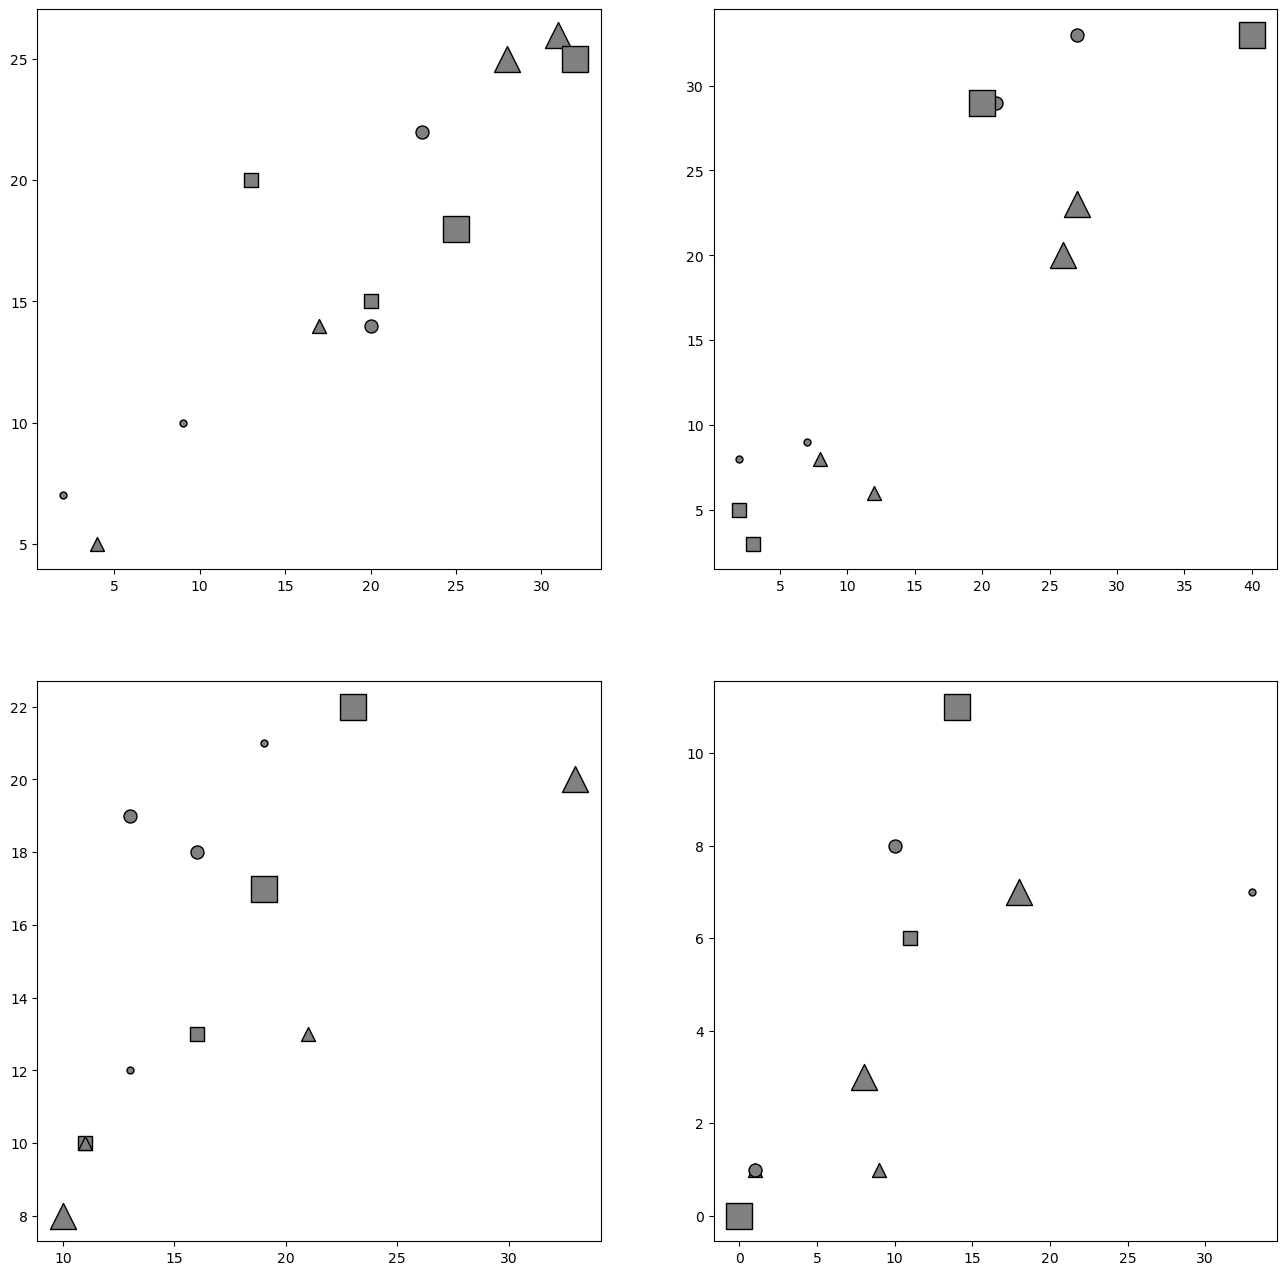

In [42]:


plimk=5
plimg=5
plimr=5
plimo=5
xd=2
yd=2
fig, ax = plt.subplots(xd,yd,figsize=(xd*8 ,yd *8))
#x = ((model_dict_seq2['tf_adage'].kegg_ps > plimk).sum(0) > 0).sum()
#y = ((model_dict_seq2['tf_adage'].kegg_ps > plimk).sum(1) > 0).sum()
#ax[0,0].scatter(x, y, c = 'yellow', marker = '*', edgecolor ='black', s=1000)
#ax[0,0].set(title = 'KEGG', xlabel = 'Total Paths', ylabel = 'Sigs with Paths')

#x = ((model_dict_da_reps['tf_adage'].go_ps > plimg).sum(0) > 0).sum()
#y = ((model_dict_da_reps['tf_adage'].go_ps > plimg).sum(1) > 0).sum()
#ax[0,1].scatter(x, y, c = 'yellow', marker = '*', edgecolor ='black', s=1000)
#ax[0,1].set(title = 'GO', xlabel = 'Total BP', ylabel = 'Sigs with BP')

#x = ((model_dict_da_reps['tf_adage'].regs_ps > plimr).sum(0) > 0).sum()
#y = ((model_dict_da_reps['tf_adage'].regs_ps > plimr).sum(1) > 0).sum()
#ax[1,0].scatter(x, y, c = 'yellow', marker = '*', edgecolor ='black', s=1000)
#ax[1,0].set(title = 'Regulons', xlabel = 'Total Regs', ylabel = 'Sigs with Regs')

#x = ((model_dict_da_reps['tf_adage'].ops_ps > plimo).sum(0) > 0).sum()
#y = ((model_dict_da_reps['tf_adage'].ops_ps > plimo).sum(1) > 0).sum()
#ax[1,1].scatter(x, y, c = 'yellow', marker = '*', edgecolor ='black', s=1000)
#ax[1,1].set(title = 'Operons', xlabel = 'Total Operons', ylabel = 'Sigs with Operons')

xi = 0
yi = 0
c = 'grey'

# edge color is tied or unties
ec = ['black','red','blue','green','purple']
eci=0

# shape is activation function
ms = ['.','s', '^','h']
mi=0

# size is L1 norm
s=50

for seed in range(1):
    for i in inits:
        s=100
    #print(i)
        for l in L1_norm:
            xi=0
            mi=0
        #print(l)
            for a in act_fun:
                m = ms[mi]
                eci=0
            #print(a)
                for t in tied:
                    name = 'ad_' + i + '_' + str(l) + '_' + a + '_tied' + str(t) + str(571)
                    print(name)
                    model_temp = model_dict_seq2[name]
                    x = ((model_temp.kegg_ps > plimk).sum(0) > 0).sum()
                    y = ((model_temp.kegg_ps > plimk).sum(1) > 0).sum()
                    ax[0,0].scatter(x, y, c = c, marker = m, edgecolor = ec[eci], s=s)
                    
                    model_temp = model_dict_seq2CTRL[name]
                    x = ((model_temp.kegg_ps > plimk).sum(0) > 0).sum()
                    y = ((model_temp.kegg_ps > plimk).sum(1) > 0).sum()
                    ax[0,1].scatter(x, y, c = c, marker = m, edgecolor = ec[eci], s=s)
                    
                    model_temp = model_dict_pre[name]
                    x = ((model_temp.kegg_ps > plimk).sum(0) > 0).sum()
                    y = ((model_temp.kegg_ps > plimk).sum(1) > 0).sum()
                    ax[1,0].scatter(x, y, c = c, marker = m, edgecolor = ec[eci], s=s)
                    
                    model_temp = model_dict_preCTRL[name]
                    x = ((model_temp.kegg_ps > plimk).sum(0) > 0).sum()
                    y = ((model_temp.kegg_ps > plimk).sum(1) > 0).sum()
                    ax[1,1].scatter(x, y, c = c, marker = m, edgecolor = ec[eci], s=s)
                    eci = eci+1
                mi = mi+1
            s=s+250
        c = 'grey'
                    


ad_glorot_uniform_0_sigmoid_tiedTrue571
ad_glorot_uniform_0_tanh_tiedTrue571
ad_glorot_uniform_0_relu_tiedTrue571
ad_glorot_uniform_1e-05_sigmoid_tiedTrue571
ad_glorot_uniform_1e-05_tanh_tiedTrue571
ad_glorot_uniform_1e-05_relu_tiedTrue571
ad_glorot_normal_0_sigmoid_tiedTrue571
ad_glorot_normal_0_tanh_tiedTrue571
ad_glorot_normal_0_relu_tiedTrue571
ad_glorot_normal_1e-05_sigmoid_tiedTrue571
ad_glorot_normal_1e-05_tanh_tiedTrue571
ad_glorot_normal_1e-05_relu_tiedTrue571


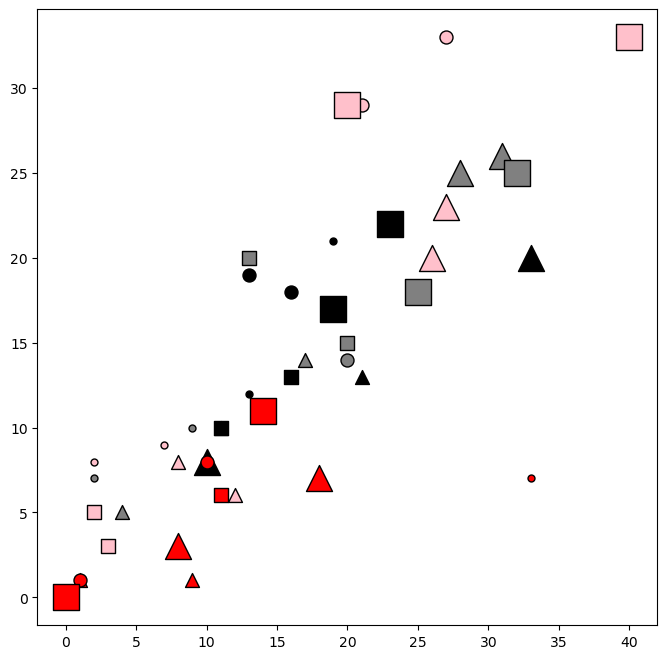

In [43]:

plimk=5
plimg=5
plimr=5
plimo=5
xd=1
yd=1
fig, ax = plt.subplots(xd,yd,figsize=(xd*8 ,yd *8))
#x = ((model_dict_seq2['tf_adage'].kegg_ps > plimk).sum(0) > 0).sum()
#y = ((model_dict_seq2['tf_adage'].kegg_ps > plimk).sum(1) > 0).sum()
#ax[0,0].scatter(x, y, c = 'yellow', marker = '*', edgecolor ='black', s=1000)
#ax[0,0].set(title = 'KEGG', xlabel = 'Total Paths', ylabel = 'Sigs with Paths')

#x = ((model_dict_da_reps['tf_adage'].go_ps > plimg).sum(0) > 0).sum()
#y = ((model_dict_da_reps['tf_adage'].go_ps > plimg).sum(1) > 0).sum()
#ax[0,1].scatter(x, y, c = 'yellow', marker = '*', edgecolor ='black', s=1000)
#ax[0,1].set(title = 'GO', xlabel = 'Total BP', ylabel = 'Sigs with BP')

#x = ((model_dict_da_reps['tf_adage'].regs_ps > plimr).sum(0) > 0).sum()
#y = ((model_dict_da_reps['tf_adage'].regs_ps > plimr).sum(1) > 0).sum()
#ax[1,0].scatter(x, y, c = 'yellow', marker = '*', edgecolor ='black', s=1000)
#ax[1,0].set(title = 'Regulons', xlabel = 'Total Regs', ylabel = 'Sigs with Regs')

#x = ((model_dict_da_reps['tf_adage'].ops_ps > plimo).sum(0) > 0).sum()
#y = ((model_dict_da_reps['tf_adage'].ops_ps > plimo).sum(1) > 0).sum()
#ax[1,1].scatter(x, y, c = 'yellow', marker = '*', edgecolor ='black', s=1000)
#ax[1,1].set(title = 'Operons', xlabel = 'Total Operons', ylabel = 'Sigs with Operons')

xi = 0
yi = 0
c = 'grey'

# edge color is tied or untied
ec = ['black','red','blue','green','purple']
eci=0

# shape is activation function
ms = ['.','s', '^','h']
mi=0

# size is L1 norm
s=50

for seed in range(1):
    for i in inits:
        s=100
    #print(i)
        for l in L1_norm:
            xi=0
            mi=0
        #print(l)
            for a in act_fun:
                m = ms[mi]
                eci=0
            #print(a)
                for t in tied:
                    name = 'ad_' + i + '_' + str(l) + '_' + a + '_tied' + str(t) + str(571)
                    print(name)
                    model_temp = model_dict_seq2[name]
                    x = ((model_temp.kegg_ps > plimk).sum(0) > 0).sum()
                    y = ((model_temp.kegg_ps > plimk).sum(1) > 0).sum()
                    ax.scatter(x, y, c = 'grey', marker = m, edgecolor = ec[eci], s=s)
                    
                    model_temp = model_dict_seq2CTRL[name]
                    x = ((model_temp.kegg_ps > plimk).sum(0) > 0).sum()
                    y = ((model_temp.kegg_ps > plimk).sum(1) > 0).sum()
                    ax.scatter(x, y, c = 'pink', marker = m, edgecolor = ec[eci], s=s)
                    
                    model_temp = model_dict_pre[name]
                    x = ((model_temp.kegg_ps > plimk).sum(0) > 0).sum()
                    y = ((model_temp.kegg_ps > plimk).sum(1) > 0).sum()
                    ax.scatter(x, y, c = 'black', marker = m, edgecolor = ec[eci], s=s)
                    
                    model_temp = model_dict_preCTRL[name]
                    x = ((model_temp.kegg_ps > plimk).sum(0) > 0).sum()
                    y = ((model_temp.kegg_ps > plimk).sum(1) > 0).sum()
                    ax.scatter(x, y, c = 'red', marker = m, edgecolor = ec[eci], s=s)
                    eci = eci+1
                mi = mi+1
            s=s+250
        c = 'grey'
                    
